First experment, described in real\science\experiment_1_celebrities\exprement_description_link.txt

Requirments to run: HF_TOKEN setted

In [46]:
import sys
from pathlib import Path
import logging

# repo root = .../VisulaiztionInfoFlowDemo  (three parents up from this notebook)
REPO_ROOT = Path.cwd().parents[2] if (Path.cwd().name == "experiment_1_celebrities") else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
CACHE_PATH = r"D:\expermient_celebrities"
ATOL = 3e-3

## 1. Data loading

### Load information to model

In [2]:
from pydantic import BaseModel


class RawSentenceData(BaseModel):
    sentence: str
    name_start_index: int
    name_end_index: int
    name: str

In [3]:
import json
import re

# Load a
with open(r"data\a_about_celebrities.json", "r", encoding="utf-8") as f:
    a_about_celebrities_dict = json.load(f)

a_about_celebrities: list[RawSentenceData] = []
for info in a_about_celebrities_dict:
    end_of_first_name_index = info["sentence"].find(" ", info["start_of_name_index"] + 1)
    end_of_last_name_index = (
        re.search(r" |'s", info["sentence"][end_of_first_name_index + 1 :]).start() + end_of_first_name_index + 1
    )
    a_about_celebrities.append(
        RawSentenceData(
            sentence=info["sentence"],
            name_start_index=info["start_of_name_index"],
            name_end_index=end_of_last_name_index,
            name=info["sentence"][info["start_of_name_index"] : end_of_last_name_index],
        )
    )


# Load b
with open(r"data\b_mentions_celebrities.json", "r", encoding="utf-8") as f:
    b_mentions_celebrities_dict = json.load(f)

b_mentions_celebrities: list[RawSentenceData] = []
for info in b_mentions_celebrities_dict:
    end_of_first_name_index = info["sentence"].find(" ", info["start_of_name_index"] + 1)
    end_of_last_name_index = (
        re.search(r" |'s", info["sentence"][end_of_first_name_index + 1 :]).start() + end_of_first_name_index + 1
    )
    b_mentions_celebrities.append(
        RawSentenceData(
            sentence=info["sentence"],
            name_start_index=info["start_of_name_index"],
            name_end_index=end_of_last_name_index,
            name=info["sentence"][info["start_of_name_index"] : end_of_last_name_index],
        )
    )

### Verify names indexes data

In [ ]:
print("A data:")
for sentece_info in a_about_celebrities:
    print(f"Sentence: {sentece_info.sentence}| Name: {sentece_info.name}")

print("--------------------------------------------------------------")
print("B data")
for sentece_info in b_mentions_celebrities:
    print(f"Sentence: {sentece_info.sentence}| Name: {sentece_info.name}")

### Load generated fake celebrities names

In [5]:
import random

with open(r"data\fake_celebrities_63_tokens.json", "r", encoding="utf-8") as f:
    alternative_names = json.load(f)
random.seed(1321)
random.shuffle(alternative_names)

### Show sums of token number are equal (model dependent)

#### Setup

In [6]:
from dotenv import load_dotenv
import os

load_dotenv(r"..\..\..\.env.local")
HF_TOKEN = os.getenv("HF_TOKEN")

In [7]:
MODEL = "meta-llama/Llama-3.1-8B"

In [8]:
from pathlib import Path
from api_checks.api_cache import ModelAPICache
from tqdm import tqdm

model_api_cache = ModelAPICache(cache_path=Path(CACHE_PATH), hf_token=HF_TOKEN)
model_calcutor = model_api_cache.get_infomration_calculator(MODEL)

#### Calculate sum tokens amount

In [9]:
def calc_sum_name_tokens_amount(raw_sentences_data: list[RawSentenceData]) -> int:
    names_total_tokens = 0
    for sentence_info in raw_sentences_data:
        tokens_num = len(model_calcutor.calc_tokens(sentence_info.name)) - 1  # Dont include BOS
        names_total_tokens += tokens_num
    return names_total_tokens


total_names_tokens_a = calc_sum_name_tokens_amount(a_about_celebrities)
total_names_tokens_b = calc_sum_name_tokens_amount(b_mentions_celebrities)

total_fake_names_tokens = 0
for name in alternative_names:
    tokens_num = len(model_calcutor.calc_tokens(name)) - 1  # Dont include BOS
    total_fake_names_tokens += tokens_num

In [10]:
assert total_names_tokens_a == total_names_tokens_b == total_fake_names_tokens
print(f"All total tokens number in names are equal to {total_names_tokens_a}")

All total tokens number in names are equal to 63


### Replace information in sentences

In [11]:
a_sentnces_fake_names = [
    raw_sentence_info.sentence.replace(raw_sentence_info.name, fake_name)
    for raw_sentence_info, fake_name in zip(a_about_celebrities, alternative_names)
]
b_sentences_fake_names = [
    raw_sentence_info.sentence.replace(raw_sentence_info.name, fake_name)
    for raw_sentence_info, fake_name in zip(b_mentions_celebrities, alternative_names)
]

In [ ]:
for i, sentence in enumerate(a_sentnces_fake_names):
    print(i, sentence)

In [ ]:
for i, sentence in enumerate(b_sentences_fake_names):
    print(i, sentence)

In [14]:
def fake_name_sentences_to_sentence_raw_data(
    sentences_with_fake_names: list[str], sentences_raw_data: list[RawSentenceData], fake_names: list[str]
) -> list[RawSentenceData]:
    result = []
    for fake_sentence, sentence_raw_data, fake_name in zip(sentences_with_fake_names, sentences_raw_data, fake_names):
        fake_sentence_raw_data = RawSentenceData(
            sentence=fake_sentence,
            name_start_index=sentence_raw_data.name_start_index,
            name_end_index=sentence_raw_data.name_start_index + len(fake_name),
            name=fake_name,
        )
        result.append(fake_sentence_raw_data)
    return result


a_fake_names_raw_data = fake_name_sentences_to_sentence_raw_data(
    a_sentnces_fake_names, a_about_celebrities, alternative_names
)
b_fake_names_raw_data = fake_name_sentences_to_sentence_raw_data(
    b_sentences_fake_names, b_mentions_celebrities, alternative_names
)

### Orgnize sentence by tokens (model dependent)

In [ ]:
class SentenceTokensInformation(BaseModel):
    sentence: str
    tokens: list[str]
    name_tokens_indexes: list[int]


def sentence_token_information_from_raw_data(raw_sentence_data: RawSentenceData, model_name: str):
    calculator = model_api_cache.get_infomration_calculator(model_name)
    sentence_tokens = calculator.calc_tokens(raw_sentence_data.sentence)

    current_character_index = 0
    current_token_index = 1  # skip BOS
    name_tokens_indexes = []
    while current_character_index < raw_sentence_data.name_start_index:
        current_character_index += len(sentence_tokens[current_token_index])
        current_token_index += 1
    if current_token_index > 1:  # Dont add BOS
        name_tokens_indexes.append(current_token_index - 1)
    while current_character_index < raw_sentence_data.name_end_index:
        name_tokens_indexes.append(current_token_index)
        current_character_index += len(sentence_tokens[current_token_index])
        current_token_index += 1

    # In case token include token name
    return SentenceTokensInformation(
        sentence=raw_sentence_data.sentence, tokens=sentence_tokens, name_tokens_indexes=name_tokens_indexes
    )

In [16]:
a_tokens_info = [
    sentence_token_information_from_raw_data(sentence_raw_data, MODEL) for sentence_raw_data in a_about_celebrities
]
a_fake_name_tokens_info = [
    sentence_token_information_from_raw_data(sentence_raw_data, MODEL) for sentence_raw_data in a_fake_names_raw_data
]
b_tokens_info = [
    sentence_token_information_from_raw_data(sentence_raw_data, MODEL) for sentence_raw_data in b_mentions_celebrities
]
b_fake_name_tokens_info = [
    sentence_token_information_from_raw_data(sentence_raw_data, MODEL) for sentence_raw_data in b_fake_names_raw_data
]

In [ ]:
a_tokens_info = (a_tokens_info, a_fake_name_tokens_info)
b_tokens_info = (b_tokens_info, b_fake_name_tokens_info)
print(a_tokens_info)

### Check that same amount of tokens after name

In [18]:
def check_same(group_tokens_info: tuple[list[SentenceTokensInformation], list[SentenceTokensInformation]]):
    for real_sent, fake_sent in zip(group_tokens_info[0], group_tokens_info[1]):
        assert len(real_sent.tokens) - max(real_sent.name_tokens_indexes) == len(fake_sent.tokens) - max(
            fake_sent.name_tokens_indexes
        ), f"Error, not same amount of tokens after name\n Real: {real_sent.tokens} | Fake: {fake_sent.tokens}"


check_same(a_tokens_info)
check_same(b_tokens_info)

## 2. load data

### Answering which matric to use, ratio or proprotions
A fundmental question to ask is which metric to use to calculate incresment in celbrity token, there are two native options:

(a) contribution_celeb/full_position : contribution_fake/full_position -> relative proprtions of position  
(b) contribution_celeb/contribution_fake : other_part_of_positon_celeb/other_part_of_position_fake -> relative ratio of proportions/ by how much token increaed with respect to other part

This comes down to the fundmental question of whether the model remix position token in other way (a), or adds a new contribution vector to the existing one (b), The decision three that intutivly dittinguish those is:
1. If position norms are relativly the same at all positions its mix -> plot norm ratios see how much they all close to 1, up to 10% is good
2. Not 1 and norms of other part are relativly the same its (b)
3. Not 1,2 If normsother parts relative to current part are high in variance, and do not increase by a relaitvly constant amount, its (b) (data is added to evrything, not constant)
4. Not 1,2,3 If norms of other part are high in varince and somtimes even decreasing, its a mix

Caveat: It has been imperaclly observed that its almost always the case that BOS has a very large norm, it could be the case that it noise the response, and its actually b, but the size of the BOS make it looks like c. I should repeat each exprement without BOC


In [19]:
import os

# Get the current working directory (home directory from which the script is run)
home_dir = os.getcwd()
print("Current working directory (home dir):", home_dir)

Current working directory (home dir): c:\Users\wildn\Desktop\New life\AI\Expirments\VisulaiztionInfoFlowDemo\real\science\experiment_1_celebrities


#### First exprment setup

In [20]:

from pydantic_settings import SettingsConfigDict

from api_checks.full_run_result import Contributions, FullRunResults
import torch

from api_checks.utils import TokenpacksIndexed, get_tokenpacks_indexed_contributions

class ResidualNorms(BaseModel):
    post_mlp_norms: torch.Tensor  # (layers,positon)
    post_attention_norms: torch.Tensor  # (layers,position)

    model_config = SettingsConfigDict(arbitrary_types_allowed=True)


class FullPositionsNormsExperimentInfo(BaseModel):
    sentence_real_tokens_info: SentenceTokensInformation
    sentence_fake_tokens_info: SentenceTokensInformation
    full_positions_relevant_norms: tuple[ResidualNorms, ResidualNorms]  # real,fake
    full_sentence_no_bos_relevant_norms: tuple[ResidualNorms, ResidualNorms]


L2_NORM = lambda x: x.norm(dim=-1)


def calc_residual_norms(
    sentence_tokens_info: SentenceTokensInformation, model_name: str, norm_func: callable = L2_NORM
) -> ResidualNorms:
    full_run_result = model_api_cache.get_full_run_results(prompt=sentence_tokens_info.sentence, model_name=model_name)
    grouped_result = get_tokenpacks_indexed_contributions(
        mask=[0] * len(sentence_tokens_info.tokens), contributions=full_run_result.contributions
    )  # (layer,residual_position,1)
    post_mlp_norms = norm_func(grouped_result.tokenpacks_contributions.post_mlp_contribution).squeeze(dim=[-1])
    post_attention_norms = norm_func(grouped_result.tokenpacks_contributions.post_attention_contribution).squeeze(
        dim=[-1]
    )
    assert len(post_mlp_norms.shape) == len(post_attention_norms.shape) == 2
    return ResidualNorms(post_mlp_norms=post_mlp_norms, post_attention_norms=post_attention_norms)


def calc_residual_norms_no_BOS(
    sentence_tokens_info: SentenceTokensInformation, model_name: str, norm_func: callable = L2_NORM
) -> ResidualNorms:
    full_run_result = model_api_cache.get_full_run_results(prompt=sentence_tokens_info.sentence, model_name=model_name)
    grouped_result = get_tokenpacks_indexed_contributions(
        mask=[0] + [1] * (len(sentence_tokens_info.tokens) - 1), contributions=full_run_result.contributions
    )  # (layer,residual,position,1)
    post_mlp_norms = norm_func(grouped_result.tokenpacks_contributions.post_mlp_contribution)[..., 1]
    post_attention_norms = norm_func(grouped_result.tokenpacks_contributions.post_attention_contribution)[..., 1]
    assert len(post_mlp_norms.shape) == len(post_attention_norms.shape) == 2
    return ResidualNorms(post_mlp_norms=post_mlp_norms, post_attention_norms=post_attention_norms)


def trim_residual_norms(residual_norms: ResidualNorms, indexes: list | range) -> ResidualNorms:
    return ResidualNorms(
        post_attention_norms=residual_norms.post_attention_norms.index_select(dim=1, index=torch.tensor(list(indexes))),
        post_mlp_norms=residual_norms.post_mlp_norms.index_select(dim=1, index=torch.tensor(list(indexes))),
    )





In [21]:
def calc_trimmed_full_position_norm_info(
    sentence_tokens_info_real: SentenceTokensInformation,
    sentence_tokens_info_fake: SentenceTokensInformation,
    model_name: str,
    norm_func: callable = L2_NORM,
):
    resdiual_norms = [
        calc_residual_norms(sentence_tokens_info_real, model_name, norm_func),
        calc_residual_norms(sentence_tokens_info_fake, model_name, norm_func),
    ]
    resdiual_norms[0] = trim_residual_norms(resdiual_norms[0], range(max(sentence_tokens_info_real.name_tokens_indexes)+1,len(sentence_tokens_info_real.tokens)))
    resdiual_norms[1] = trim_residual_norms(resdiual_norms[1], range(max(sentence_tokens_info_fake.name_tokens_indexes)+1,len(sentence_tokens_info_fake.tokens)))

    resdiual_no_bos_norms = [
        calc_residual_norms_no_BOS(sentence_tokens_info_real, model_name, norm_func),
        calc_residual_norms_no_BOS(sentence_tokens_info_fake, model_name, norm_func),
    ]
    resdiual_no_bos_norms[0] = trim_residual_norms(resdiual_no_bos_norms[0], range(max(sentence_tokens_info_real.name_tokens_indexes)+1,len(sentence_tokens_info_real.tokens)))
    resdiual_no_bos_norms[1] = trim_residual_norms(resdiual_no_bos_norms[1], range(max(sentence_tokens_info_fake.name_tokens_indexes)+1,len(sentence_tokens_info_fake.tokens)))
    return FullPositionsNormsExperimentInfo(
        sentence_real_tokens_info=sentence_tokens_info_real,
        sentence_fake_tokens_info=sentence_tokens_info_fake,
        full_positions_relevant_norms=tuple(resdiual_norms),
        full_sentence_no_bos_relevant_norms=tuple(resdiual_no_bos_norms),
    )

In [ ]:
about_celebrities_expriment_info:FullPositionsNormsExperimentInfo = []
for (real_sentence,fake_sentence) in tqdm((list(zip(*a_tokens_info))+list(zip(*a_tokens_info)))):
    about_celebrities_expriment_info.append(calc_trimmed_full_position_norm_info(real_sentence,fake_sentence,model_name=MODEL))

#### First expriment data gathering

#### sainity checks

In [ ]:
position_norm_expirment_info:list[FullPositionsNormsExperimentInfo] = about_celebrities_expriment_info
for expirment_info in position_norm_expirment_info:
    assert expirment_info.sentence_real_tokens_info.tokens[max(expirment_info.sentence_real_tokens_info.name_tokens_indexes)+1:] == expirment_info.sentence_fake_tokens_info.tokens[max(expirment_info.sentence_fake_tokens_info.name_tokens_indexes)+1:]
    print(f"{expirment_info.sentence_real_tokens_info.tokens[min(expirment_info.sentence_real_tokens_info.name_tokens_indexes):max(expirment_info.sentence_real_tokens_info.name_tokens_indexes)+1]}| {expirment_info.sentence_fake_tokens_info.tokens[min(expirment_info.sentence_fake_tokens_info.name_tokens_indexes):max(expirment_info.sentence_fake_tokens_info.name_tokens_indexes)+1]}")
    num_of_post_names_tokens = len(expirment_info.sentence_real_tokens_info.tokens[max(expirment_info.sentence_real_tokens_info.name_tokens_indexes)+1:])
    print(num_of_post_names_tokens)
    assert num_of_post_names_tokens == expirment_info.full_positions_relevant_norms[0].post_attention_norms.shape[1] == expirment_info.full_positions_relevant_norms[0].post_mlp_norms.shape[1]
    assert num_of_post_names_tokens == expirment_info.full_positions_relevant_norms[1].post_attention_norms.shape[1] == expirment_info.full_positions_relevant_norms[1].post_mlp_norms.shape[1]
    assert num_of_post_names_tokens == expirment_info.full_sentence_no_bos_relevant_norms[0].post_attention_norms.shape[1] == expirment_info.full_sentence_no_bos_relevant_norms[0].post_mlp_norms.shape[1]
    assert num_of_post_names_tokens == expirment_info.full_sentence_no_bos_relevant_norms[1].post_attention_norms.shape[1] == expirment_info.full_sentence_no_bos_relevant_norms[1].post_mlp_norms.shape[1]

#### Plot full norms change

In [ ]:
full_position_ratio_attention = torch.cat([(exp_info.full_positions_relevant_norms[0].post_attention_norms/exp_info.full_positions_relevant_norms[1].post_attention_norms).flatten() for exp_info in position_norm_expirment_info])
full_position_ratio_mlp = torch.cat([(exp_info.full_positions_relevant_norms[0].post_mlp_norms/exp_info.full_positions_relevant_norms[1].post_mlp_norms).flatten() for exp_info in position_norm_expirment_info])
full_position_ratios = torch.cat([full_position_ratio_attention,full_position_ratio_mlp])



In [109]:
#VIBECODED
import matplotlib.pyplot as plt
import numpy as np



def plot_ratio_hist(flat: torch.Tensor, bins: int = 80):
    x = flat.detach().float().cpu().numpy()
    x = x[np.isfinite(x)]
    mean = x.mean()
    geo_mean = np.exp(np.log(x).mean())  # geometric mean, natural for ratios
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(x, bins=bins, color="#4c72b0", edgecolor="white", linewidth=0.3)
    ax.axvline(1.0, color="#c44e52", linewidth=1.2)
    ax.axvline(mean, color="#333333", linewidth=1.0, linestyle="--")
    ax.axvline(geo_mean, color="#55a868", linewidth=1.0, linestyle="--")
    # values on the x-axis, stacked at different heights so they never overlap
    ax.text(mean, -0.06, f"{mean:.3f}", ha="center", va="top",
            color="#333333", fontweight="bold", transform=ax.get_xaxis_transform())
    ax.text(geo_mean, -0.13, f"{geo_mean:.3f}", ha="center", va="top",
            color="#55a868", fontweight="bold", transform=ax.get_xaxis_transform())
    # legend so the two dashed lines are distinguishable
    ax.plot([], [], color="#333333", linestyle="--", label="mean")
    ax.plot([], [], color="#55a868", linestyle="--", label="geom. mean")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlabel("ratio")
    ax.set_ylabel("count")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

plot_ratio_hist(full_position_ratios)


NameError: name 'full_position_ratios' is not defined

Seems like not that much change,lets see how no bos is

In [ ]:
full_position_no_bos_ratio_attention = torch.cat([(exp_info.full_sentence_no_bos_relevant_norms[0].post_attention_norms/exp_info.full_sentence_no_bos_relevant_norms[1].post_attention_norms).flatten() for exp_info in position_norm_expirment_info])
full_position_no_bos_ratio_mlp = torch.cat([(exp_info.full_sentence_no_bos_relevant_norms[0].post_mlp_norms/exp_info.full_sentence_no_bos_relevant_norms[1].post_mlp_norms).flatten() for exp_info in position_norm_expirment_info])
full_position_no_bos_ratios = torch.cat([full_position_no_bos_ratio_attention,full_position_no_bos_ratio_mlp])



In [ ]:
plot_ratio_hist(full_position_no_bos_ratios)

No BOS mean norms ratio is still very close to 1, not enoguh change to be sagnificant

plot_ratio_hist(full_position_ratios)


### Conclusion 
The remixing (a) perspective is the most accurate, and the one that it will be used   
contribution_celeb/full_position : contribution_fake/full_position -> relative proprtions of position 

If exprmient show negative result on some cases (norm dosent increase) (for example, on all last layers, norm dosent increase) revise, and plot again only on other cases

In [23]:
def relative_norm_increasment(
    celeb_contribution_norm: float,
    celeb_position_contribution_norm: float,
    fake_celeb_contribution_norm: float,
    fake_celeb_position_norm: float,
) -> float:
    return (celeb_contribution_norm / celeb_position_contribution_norm) / (fake_celeb_contribution_norm / fake_celeb_position_norm)

## Expirment 2

### Eache expremtn (a and b) will be saved as ExpermentPair containing the
- Tokenpakcs information (same as tokens informatio but with name as one token)
- The cottributions norms of the tokenpacks

In [84]:


class ContributionsNorms(BaseModel):
    post_attention_contributions_norms: torch.Tensor  # (layer,position (prompt_len_after_name),source (prompt_len))
    post_mlp_contributions_norms: torch.Tensor  # (layer,position (prompt_len_after_name),source (prompt_len))

    model_config = SettingsConfigDict(arbitrary_types_allowed=True)


class SentenceTokenPacksInformation(BaseModel):
    sentence: str
    tokenpacks: list[str]
    name_token_index: int
    original_tokens_info: SentenceTokensInformation


class ExprimentPair(BaseModel):
    real_names: tuple[SentenceTokenPacksInformation, ContributionsNorms]
    fake_names: tuple[SentenceTokenPacksInformation, ContributionsNorms]

#### Util functions for converting data formats

In [174]:
def _contributions_to_contributions_norm(
    contributions: Contributions, norm_func: callable = lambda x: x.norm(dim=-1)
) -> ContributionsNorms:
    post_attention_contributions_norms = norm_func(contributions.post_attention_contribution)
    post_mlp_contributions_norms = norm_func(contributions.post_mlp_contribution)
    return ContributionsNorms(
        post_attention_contributions_norms=post_attention_contributions_norms,
        post_mlp_contributions_norms=post_mlp_contributions_norms,
    )


def _mask_by_celeb_name(
    sentence_tokens_info: SentenceTokensInformation, contributions: Contributions
) -> tuple[SentenceTokenPacksInformation, TokenpacksIndexed]:
    mask = [0]
    token_packs = [sentence_tokens_info.tokens[0]]
    sentence_tokens = sentence_tokens_info.tokens
    name_index = None
    for i in range(1, len(sentence_tokens)):
        if i not in sentence_tokens_info.name_tokens_indexes[1:]:
            mask.append(mask[i - 1] + 1)
            token_packs.append(sentence_tokens[i])
        else:
            name_index = mask[i - 1]
            mask.append(mask[i - 1])
            token_packs[mask[i - 1]] += sentence_tokens[i]
    tokenpacks_indexed_contributions = get_tokenpacks_indexed_contributions(
        mask, contributions, tokens=sentence_tokens_info.tokens
    )
    assert tokenpacks_indexed_contributions.tokenpacks == token_packs  # same thing, calculated to get the name index
    sentence_tokenpacks_information = SentenceTokenPacksInformation(
        sentence=sentence_tokens_info.sentence, tokenpacks=token_packs, name_token_index=name_index,original_tokens_info=sentence_tokens_info
    )
    return (sentence_tokenpacks_information, tokenpacks_indexed_contributions)

### Calculate the experment info

1. Trace contributions
2. tokenpack name
3. calc norm

In [175]:
def trace_full_norms(
    sentence_tokens_info: SentenceTokensInformation, model: str
) -> tuple[SentenceTokenPacksInformation, ContributionsNorms]:
    sent_full_run_result = model_api_cache.get_full_run_results(model_name=model, prompt=sentence_tokens_info.sentence)
    sentence_token_packs_info, contributions_grouped_by_celeb = _mask_by_celeb_name(
        sentence_tokens_info, sent_full_run_result.contributions
    )
    sent_contributions_norms = _contributions_to_contributions_norm(
        contributions_grouped_by_celeb.tokenpacks_contributions
    )
    return sentence_token_packs_info, sent_contributions_norms


def calculate_expirment_info(
    group_tokens_info: tuple[list[SentenceTokensInformation], list[SentenceTokensInformation]], model: str
) -> list[ExprimentPair]:
    experiment_group = []
    for real_sent, fake_sent in tqdm(zip(group_tokens_info[0], group_tokens_info[1])):
        expriment_pair = ExprimentPair(
            real_names=trace_full_norms(real_sent, model=model),
            fake_names=trace_full_norms(fake_sent, model=model),
        )
        experiment_group.append(expriment_pair)
    return experiment_group

In [176]:
import nnsight

nnsight.CONFIG.APP.REMOTE_LOGGING = False

In [ ]:
a_experiment_info = calculate_expirment_info(a_tokens_info,model=MODEL)
b_expiriment_info = calculate_expirment_info(b_tokens_info,model=MODEL)

#### Validate name in index
Should produce only names and lists of token with names groupd

In [ ]:
for ei in a_experiment_info:
    print(ei.real_names[0].tokenpacks)
    print(ei.fake_names[0].tokenpacks)
    print(ei.real_names[0].tokenpacks[ei.real_names[0].name_token_index])
    print(ei.fake_names[0].tokenpacks[ei.fake_names[0].name_token_index])
    assert ei.real_names[0].name_token_index == ei.fake_names[0].name_token_index
print("Expirment B")
for ei in b_expiriment_info:
    print(ei.fake_names[0].tokenpacks)
    print(ei.fake_names[0].tokenpacks)
    print(ei.real_names[0].tokenpacks[ei.real_names[0].name_token_index])
    print(ei.fake_names[0].tokenpacks[ei.fake_names[0].name_token_index])
    assert ei.real_names[0].name_token_index == ei.fake_names[0].name_token_index

Calc full residual norms per group

In [90]:
def calc_full_position_norm_info(
    sentence_tokens_info_real: SentenceTokensInformation,
    sentence_tokens_info_fake: SentenceTokensInformation,
    model_name: str,
    norm_func: callable = L2_NORM,
):
    resdiual_norms = (
        calc_residual_norms(sentence_tokens_info_real, model_name, norm_func),
        calc_residual_norms(sentence_tokens_info_fake, model_name, norm_func)
    )
    resdiual_no_bos_norms = (
        calc_residual_norms_no_BOS(sentence_tokens_info_real, model_name, norm_func),
        calc_residual_norms_no_BOS(sentence_tokens_info_fake, model_name, norm_func),
    )
    return FullPositionsNormsExperimentInfo(
        sentence_real_tokens_info=sentence_tokens_info_real,
        sentence_fake_tokens_info=sentence_tokens_info_fake,
        full_positions_relevant_norms=tuple(resdiual_norms),
        full_sentence_no_bos_relevant_norms=tuple(resdiual_no_bos_norms),
    )

In [ ]:
a_full_norms_ei: list[FullPositionsNormsExperimentInfo] = []
for real_sentence, fake_sentence in tqdm(list(zip(*a_tokens_info))):
    a_full_norms_ei.append(calc_full_position_norm_info(real_sentence, fake_sentence, model_name=MODEL))
b_full_norms_ei: list[FullPositionsNormsExperimentInfo] = []
for real_sentence, fake_sentence in tqdm(list(zip(*b_tokens_info))):
    b_full_norms_ei.append(calc_full_position_norm_info(real_sentence, fake_sentence, model_name=MODEL))

In [93]:
# It should be noted that this is not a ratio in the traditional sense of all ratios sum to 1, and actually due to the traingle enawulity it should sum to >=1
class ContributionsPositionsNormsRatio(BaseModel):
    post_attention_ratios: torch.Tensor # (layers, position,tokenpacks (source))
    post_mlp_ratios: torch.Tensor # (layers, position,tokenpacks (source))
    
    model_config = SettingsConfigDict(arbitrary_types_allowed=True)

class ContributionsPositionsRatiosExpirmentInfo(BaseModel):
    real_names_tokenpacks_info : SentenceTokenPacksInformation
    fake_names_tokenpacks_info: SentenceTokenPacksInformation
    real_norm_ratios: ContributionsPositionsNormsRatio
    fake_norm_ratios: ContributionsPositionsNormsRatio
    



In [180]:
# import icecream as ic
a_ratios_ei:list[ContributionsPositionsRatiosExpirmentInfo] = []
for (full_norms_ei,contributions_ei) in zip(a_full_norms_ei,a_experiment_info):
    fake_norm_ratios_mlp = contributions_ei.fake_names[1].post_mlp_contributions_norms / full_norms_ei.full_positions_relevant_norms[1].post_mlp_norms.unsqueeze(dim=2)
    fake_norm_ratios_attention = contributions_ei.fake_names[1].post_attention_contributions_norms/ full_norms_ei.full_positions_relevant_norms[1].post_attention_norms.unsqueeze(dim=2)
    
    
    real_norm_ratios_mlp = contributions_ei.real_names[1].post_mlp_contributions_norms/ full_norms_ei.full_positions_relevant_norms[0].post_mlp_norms.unsqueeze(dim=2) #(laeryers,positions,token_packs)/(layers,positions,1)
    real_norm_ratios_attention = contributions_ei.real_names[1].post_attention_contributions_norms / full_norms_ei.full_positions_relevant_norms[0].post_attention_norms.unsqueeze(dim=2)
    contributions_positions_ei = ContributionsPositionsRatiosExpirmentInfo(
        real_names_tokenpacks_info =  contributions_ei.real_names[0],
        fake_names_tokenpacks_info = contributions_ei.fake_names[0],
        real_norm_ratios = ContributionsPositionsNormsRatio(post_mlp_ratios = real_norm_ratios_mlp,post_attention_ratios=real_norm_ratios_attention),
        fake_norm_ratios = ContributionsPositionsNormsRatio(post_mlp_ratios = fake_norm_ratios_mlp,post_attention_ratios = fake_norm_ratios_attention)
        
    )
    a_ratios_ei.append(contributions_positions_ei)
    
   
   
   
b_ratios_ei:list[ContributionsPositionsRatiosExpirmentInfo] = []
for (full_norms_ei,contributions_ei) in zip(b_full_norms_ei,b_expiriment_info):
    fake_norm_ratios_mlp = contributions_ei.fake_names[1].post_mlp_contributions_norms / full_norms_ei.full_positions_relevant_norms[1].post_mlp_norms.unsqueeze(dim=2)
    fake_norm_ratios_attention = contributions_ei.fake_names[1].post_attention_contributions_norms/ full_norms_ei.full_positions_relevant_norms[1].post_attention_norms.unsqueeze(dim=2)
    
    
    real_norm_ratios_mlp = contributions_ei.real_names[1].post_mlp_contributions_norms/ full_norms_ei.full_positions_relevant_norms[0].post_mlp_norms.unsqueeze(dim=2) #(laeryers,positions,token_packs)/(layers,positions,1)
    real_norm_ratios_attention = contributions_ei.real_names[1].post_attention_contributions_norms / full_norms_ei.full_positions_relevant_norms[0].post_attention_norms.unsqueeze(dim=2)
    
    contributions_positions_ei = ContributionsPositionsRatiosExpirmentInfo(
        real_names_tokenpacks_info =  contributions_ei.real_names[0],
        fake_names_tokenpacks_info = contributions_ei.fake_names[0],
        real_norm_ratios = ContributionsPositionsNormsRatio(post_mlp_ratios = real_norm_ratios_mlp,post_attention_ratios=real_norm_ratios_attention),
        fake_norm_ratios = ContributionsPositionsNormsRatio(post_mlp_ratios = fake_norm_ratios_mlp,post_attention_ratios = fake_norm_ratios_attention)
        
    )
    b_ratios_ei.append(contributions_positions_ei)




In [181]:
def sainty_check_ratios_ei(ratios_ei:list[ContributionsPositionsRatiosExpirmentInfo]):
    for ei in ratios_ei:
        assert ei.real_names_tokenpacks_info.name_token_index == ei.fake_names_tokenpacks_info.name_token_index # Same start index of name
        name_index = ei.real_names_tokenpacks_info.name_token_index
        assert ei.real_names_tokenpacks_info.tokenpacks[:name_index] == ei.fake_names_tokenpacks_info.tokenpacks[:name_index] #Before name equal tokenpacks
        assert ei.real_names_tokenpacks_info.tokenpacks[name_index+1:] == ei.fake_names_tokenpacks_info.tokenpacks[name_index+1:] #After name equal tokenpacks
        
        start_real_name_token_index ,start_fake_name_token_index =  min(ei.real_names_tokenpacks_info.original_tokens_info.name_tokens_indexes), min(ei.fake_names_tokenpacks_info.original_tokens_info.name_tokens_indexes)
        end_real_name_token_index,end_fake_name_token_index =  max(ei.real_names_tokenpacks_info.original_tokens_info.name_tokens_indexes), max(ei.fake_names_tokenpacks_info.original_tokens_info.name_tokens_indexes)
        
        assert start_real_name_token_index == start_fake_name_token_index # name starts in same token
        assert ei.real_names_tokenpacks_info.original_tokens_info.tokens[:start_real_name_token_index] == ei.fake_names_tokenpacks_info.original_tokens_info.tokens[:start_fake_name_token_index] #Before name equal tokens
        assert ei.real_names_tokenpacks_info.original_tokens_info.tokens[end_real_name_token_index+1:] == ei.fake_names_tokenpacks_info.original_tokens_info.tokens[end_fake_name_token_index+1:] # After name equal tokenpacks
        
        assert ei.real_norm_ratios.post_attention_ratios[:,(end_real_name_token_index+1):,:].shape[1] == len(ei.fake_names_tokenpacks_info.original_tokens_info.tokens[end_fake_name_token_index+1:]) # number of tokens after namelin post attention real equal number of tokens after name in fake (could have done )


        assert torch.allclose(ei.real_norm_ratios.post_attention_ratios[:,:name_index,:],ei.fake_norm_ratios.post_attention_ratios[:,:name_index,:],atol =ATOL) #attention ratios equal before name
        assert torch.allclose(ei.real_norm_ratios.post_mlp_ratios[:,:name_index,:],ei.fake_norm_ratios.post_mlp_ratios[:,:name_index,:],atol = ATOL) # mlp ratios equal before names
        
sainty_check_ratios_ei(a_ratios_ei)
sainty_check_ratios_ei(b_ratios_ei)

In [101]:
#Bothe ends of segments are included
EARLY_LAYER_SEGMENT = (0,10)
MID_LAYERS_SEGMENT = (11,20)
END_LAYERS_SEGMENT = (21,31)

In [ ]:
# Returns all expirment info in layers segments and after name mentioned


def get_relevant_norms_metrics(
    ratios_ei: list[ContributionsPositionsRatiosExpirmentInfo],
) -> list[torch.Tensor]:  # sentence,({attention,mlp},layer,positon(after name)):
    result_list: list[torch.Tensor] = []
    for ratio_ei in ratios_ei:
        name_tokenpack_index = ratio_ei.real_names_tokenpacks_info.name_token_index
        name_real_end_token_index, name_fake_end_token_index = max(ratio_ei.real_names_tokenpacks_info.original_tokens_info.name_tokens_indexes), max(ratio_ei.fake_names_tokenpacks_info.original_tokens_info.name_tokens_indexes) 
        print(ratio_ei.real_norm_ratios.post_attention_ratios[:, (name_real_end_token_index + 1) :, :][..., name_tokenpack_index].shape)
        print(ratio_ei.fake_norm_ratios.post_attention_ratios[:, (name_fake_end_token_index + 1) :, :][..., name_tokenpack_index].shape)
        attention_metric_tensor = (
            ratio_ei.real_norm_ratios.post_attention_ratios[:, (name_real_end_token_index + 1) :, :][..., name_tokenpack_index]
            / ratio_ei.fake_norm_ratios.post_attention_ratios[:, (name_fake_end_token_index + 1) :, :][..., name_tokenpack_index]
        )
        mlp_metric_tensor = (
            ratio_ei.real_norm_ratios.post_mlp_ratios[:, (name_real_end_token_index + 1) :, :][..., name_tokenpack_index]
            / ratio_ei.fake_norm_ratios.post_mlp_ratios[:, (name_fake_end_token_index + 1) :, :][..., name_tokenpack_index]
        )
        metric_tensor = torch.stack([attention_metric_tensor, mlp_metric_tensor])
        assert len(metric_tensor.shape) == 3
        result_list.append(metric_tensor)

    return result_list 


a_about_celebrities_metrics_list = get_relevant_norms_metrics(a_ratios_ei)
b_mentioned_celbrities_metrixs_list = get_relevant_norms_metrics(b_ratios_ei)


In [160]:
print(a_about_celebrities_metrics_list[0].shape)
a_early_group = torch.cat([a[:,EARLY_LAYER_SEGMENT[0]:EARLY_LAYER_SEGMENT[1]+1,:].flatten() for a in a_about_celebrities_metrics_list])
a_mid_group = torch.cat([a[:,MID_LAYERS_SEGMENT[0]:MID_LAYERS_SEGMENT[1]+1,:].flatten() for a in a_about_celebrities_metrics_list])
a_last_group = torch.cat([a[:,END_LAYERS_SEGMENT[0]:END_LAYERS_SEGMENT[1]+1,:].flatten() for a in a_about_celebrities_metrics_list])

print(b_mentioned_celbrities_metrixs_list[0].shape)
b_early_group = torch.cat([a[:,EARLY_LAYER_SEGMENT[0]:EARLY_LAYER_SEGMENT[1]+1,:].flatten() for a in b_mentioned_celbrities_metrixs_list])
b_mid_group = torch.cat([a[:,MID_LAYERS_SEGMENT[0]:MID_LAYERS_SEGMENT[1]+1,:].flatten() for a in b_mentioned_celbrities_metrixs_list])
b_last_group = torch.cat([a[:,END_LAYERS_SEGMENT[0]:END_LAYERS_SEGMENT[1]+1,:].flatten() for a in b_mentioned_celbrities_metrixs_list])

torch.Size([2, 32, 18])
torch.Size([2, 32, 5])


In [168]:
##VIBECODED
import matplotlib.ticker as mticker

def plot_by_groups_log_scale(early_layers:torch.Tensor,mid_layers:torch.tensor,last_layers:torch.tensor,suptitle:str|None=None,bins:int=80,ratio_extent:float|None=None)->None:#input dime (sentncesx layers(in group)xpoisiton (after name))
    tensors = [early_layers, mid_layers, last_layers]
    titles = ["Early layers", "Mid layers", "Last layers"]

    # --- prep all data once ---
    xs = []
    for t in tensors:
        x = t.detach().float().cpu().numpy().ravel()
        x = x[np.isfinite(x)]
        assert (x > 0).all()
        xs.append(x)

    # reuse a previous plot's scale if given; otherwise derive from data
    if ratio_extent is None:
        gmin = min(x.min() for x in xs)
        gmax = max(x.max() for x in xs)
        ratio_extent = max(1.0 / gmin, gmax)   # farthest ratio from 1, either side

    # symmetric, log-spaced bins from 1/ratio_extent to ratio_extent (centered on 1)
    edges = np.logspace(np.log10(1.0 / ratio_extent), np.log10(ratio_extent), bins + 1)

    # tick positions: integers 1..9 per decade (up to ratio_extent) and their reciprocals
    pos = []
    for exp in range(0, int(np.ceil(np.log10(ratio_extent))) + 1):
        for d in range(1, 10):
            v = d * 10.0 ** exp
            if v <= ratio_extent * 1.0001:
                pos.append(v)
    ticks = sorted(set(pos + [1.0 / v for v in pos]))

    def ratio_fmt(v, _=None):
        if v >= 1:
            return f"{round(v):g}"
        r = 1.0 / v
        return f"1/{round(r):g}"

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True, sharey=True)

    for ax, x, title in zip(axes, xs, titles):
        geo_mean = np.exp(np.log(x).mean())

        ax.hist(x, bins=edges, color="#4c72b0", edgecolor="white", linewidth=0.3)
        ax.set_xscale("log")
        ax.set_xlim(1.0 / ratio_extent, ratio_extent)   # symmetric around 1

        ax.xaxis.set_major_locator(mticker.FixedLocator(ticks))
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(ratio_fmt))
        ax.xaxis.set_minor_locator(mticker.NullLocator())
        ax.tick_params(axis="x", which="major", labelsize=7, rotation=90)

        ax.axvline(1.0, color="#c44e52", linewidth=1.2)
        ax.axvline(geo_mean, color="#55a868", linewidth=1.0, linestyle="--")

        ax.text(geo_mean, -0.06, f"{geo_mean:.3f}", ha="center", va="top",
                color="#55a868", fontweight="bold",
                transform=ax.get_xaxis_transform())

        ax.plot([], [], color="#55a868", linestyle="--", label="geom. mean")

        ax.set_title(title)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xlabel("ratio")
        ax.set_ylabel("count")
        ax.legend(frameon=False)

    if suptitle is not None:
        fig.suptitle(suptitle)

    plt.tight_layout()
    plt.show()

    return ratio_extent


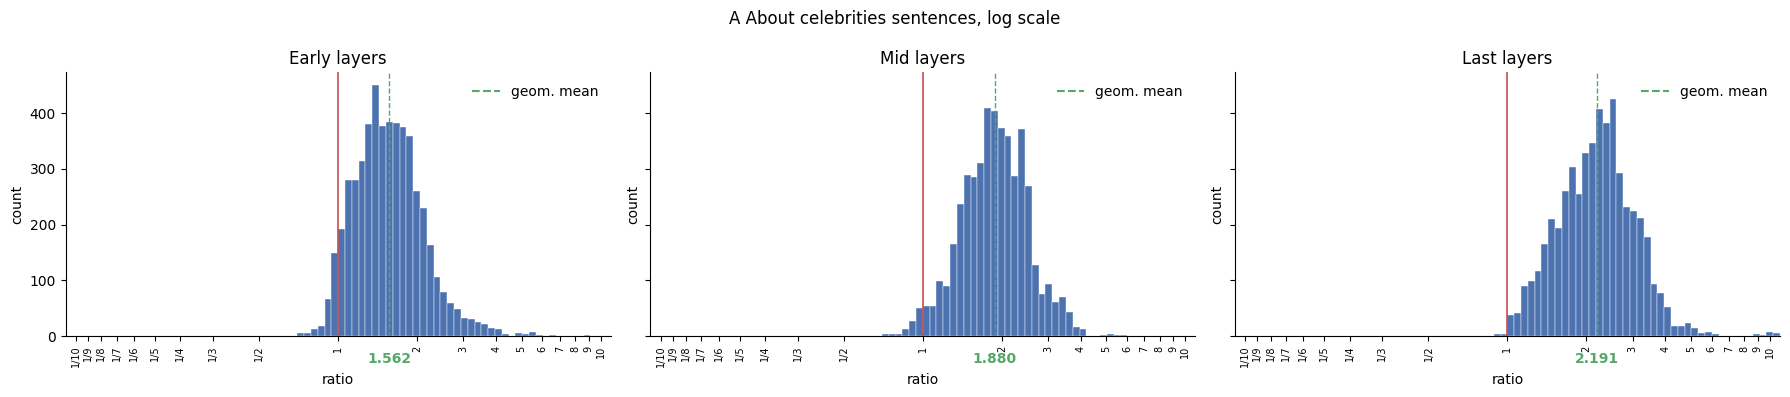

In [ ]:
ratio_extent = plot_by_groups_log_scale(a_early_group,a_mid_group,a_last_group, "A About celebrities sentences, log scale")


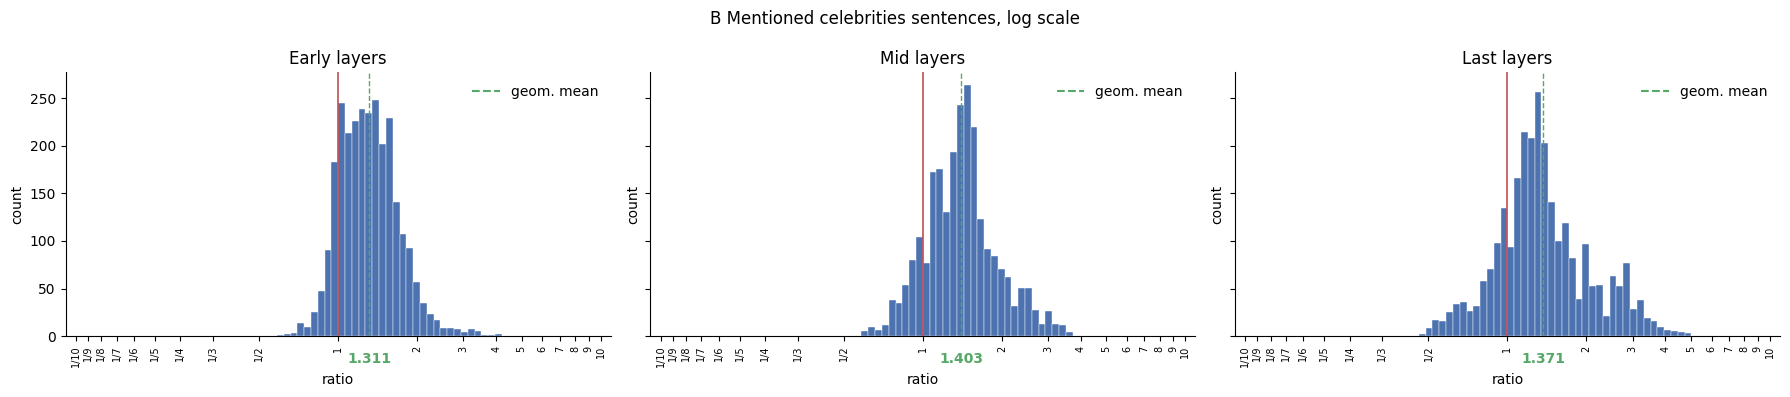

np.float32(10.947543)

In [167]:
plot_by_groups_log_scale(b_early_group,b_mid_group,b_last_group, "B Mentioned celebrities sentences, log scale",ratio_extent=ratio_extent)

### Sentencewise Observations
trying to find patterns in sentences, this part is vibed

### Inspect smaller then 1 in tensors

In [182]:
print(a_about_celebrities_metrics_list[0].shape)
a_early_group_list = [a[:,EARLY_LAYER_SEGMENT[0]:EARLY_LAYER_SEGMENT[1]+1,:] for a in a_about_celebrities_metrics_list]
a_mid_group_list = [a[:,MID_LAYERS_SEGMENT[0]:MID_LAYERS_SEGMENT[1]+1,:] for a in a_about_celebrities_metrics_list]
a_last_group_list = [a[:,END_LAYERS_SEGMENT[0]:END_LAYERS_SEGMENT[1]+1,:] for a in a_about_celebrities_metrics_list]

print(b_mentioned_celbrities_metrixs_list[0].shape)
b_early_group_list = [a[:,EARLY_LAYER_SEGMENT[0]:EARLY_LAYER_SEGMENT[1]+1,:] for a in b_mentioned_celbrities_metrixs_list]
b_mid_group_list = [a[:,MID_LAYERS_SEGMENT[0]:MID_LAYERS_SEGMENT[1]+1,:] for a in b_mentioned_celbrities_metrixs_list]
b_last_group_list = [a[:,END_LAYERS_SEGMENT[0]:END_LAYERS_SEGMENT[1]+1,:] for a in b_mentioned_celbrities_metrixs_list]
                              
                              
                              

torch.Size([2, 32, 18])
torch.Size([2, 32, 5])


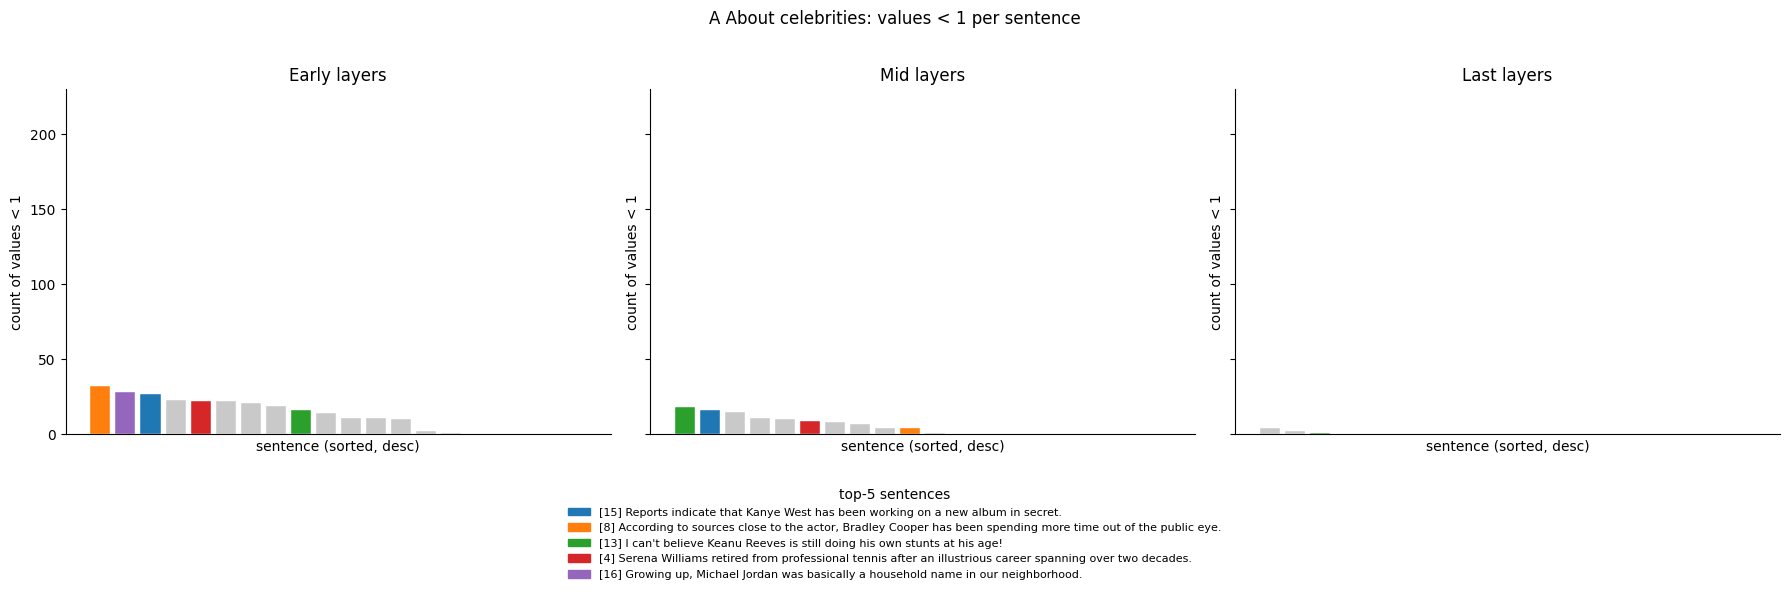

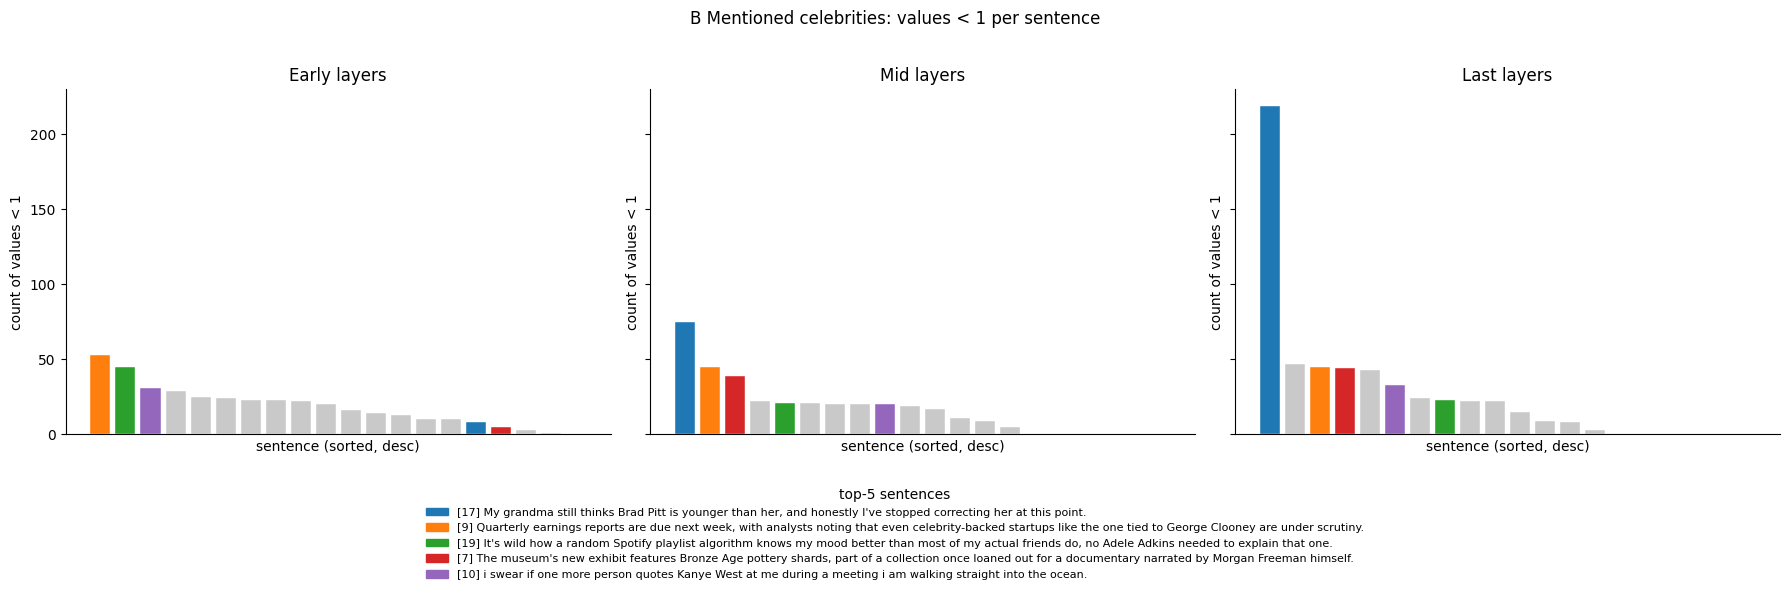

In [184]:
#VIBECODED
# Count of metric values < 1 (celeb proportion DECREASED vs fake) PER SENTENCE,
# faceted by layer-group, one figure per experiment (A / B).
#   - bars sorted descending within each facet
#   - shared y-scale across BOTH A and B figures
#   - top-5 sentences (by total count over the three groups) color-coded, with a
#     legend BELOW the plot showing the FULL sentence text.
# metric_group layout: (part {attn, mlp}, layers_in_group, position_after_name)

GROUP_ORDER = ["Early", "Mid", "Last"]
GRAY = "#c9c9c9"


def counts_per_sentence(group_list):
    return np.array([int((g < 1).sum().item()) for g in group_list])


def experiment_counts(groups_with_lists):
    return {name: counts_per_sentence(gl) for name, gl in groups_with_lists}


def plot_experiment(exp_label, counts_by_group, sentences, top5_idx, color_of, ymax):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
    for ax, group_name in zip(axes, GROUP_ORDER):
        counts = counts_by_group[group_name]
        order = np.argsort(counts)[::-1]  # descending
        colors = [color_of.get(i, GRAY) for i in order]
        ax.bar(np.arange(len(counts)), counts[order], color=colors, edgecolor="white", linewidth=0.3)
        ax.set_title(f"{group_name} layers")
        ax.set_xlabel("sentence (sorted, desc)")
        ax.set_ylabel("count of values < 1")
        ax.set_ylim(0, ymax)
        ax.set_xticks([])
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    fig.suptitle(f"{exp_label}: values < 1 per sentence", y=1.02)
    # legend BELOW the plots (full sentence text), so it never overlaps the bars
    handles = [plt.Rectangle((0, 0), 1, 1, color=color_of[i]) for i in top5_idx]
    labels = [f"[{i}] {sentences[i]}" for i in top5_idx]
    fig.legend(handles, labels, frameon=False, fontsize=8, loc="upper center",
               bbox_to_anchor=(0.5, -0.02), ncol=1, title="top-5 sentences")
    plt.tight_layout()
    plt.show()


a_groups = [("Early", a_early_group_list), ("Mid", a_mid_group_list), ("Last", a_last_group_list)]
b_groups = [("Early", b_early_group_list), ("Mid", b_mid_group_list), ("Last", b_last_group_list)]

a_counts = experiment_counts(a_groups)
b_counts = experiment_counts(b_groups)

a_sentences = [r.real_names_tokenpacks_info.sentence for r in a_ratios_ei]
b_sentences = [r.real_names_tokenpacks_info.sentence for r in b_ratios_ei]

# top-5 sentences per experiment by total count across the three layer-groups
a_totals = sum(a_counts[g] for g in GROUP_ORDER)
b_totals = sum(b_counts[g] for g in GROUP_ORDER)
a_top5 = list(np.argsort(a_totals)[::-1][:5])
b_top5 = list(np.argsort(b_totals)[::-1][:5])

palette = plt.get_cmap("tab10").colors
a_color_of = {idx: palette[k] for k, idx in enumerate(a_top5)}
b_color_of = {idx: palette[k] for k, idx in enumerate(b_top5)}

# shared y-scale across BOTH experiments
ymax = max(
    max(c.max() for c in a_counts.values()),
    max(c.max() for c in b_counts.values()),
) * 1.05

plot_experiment("A About celebrities", a_counts, a_sentences, a_top5, a_color_of, ymax)
plot_experiment("B Mentioned celebrities", b_counts, b_sentences, b_top5, b_color_of, ymax)


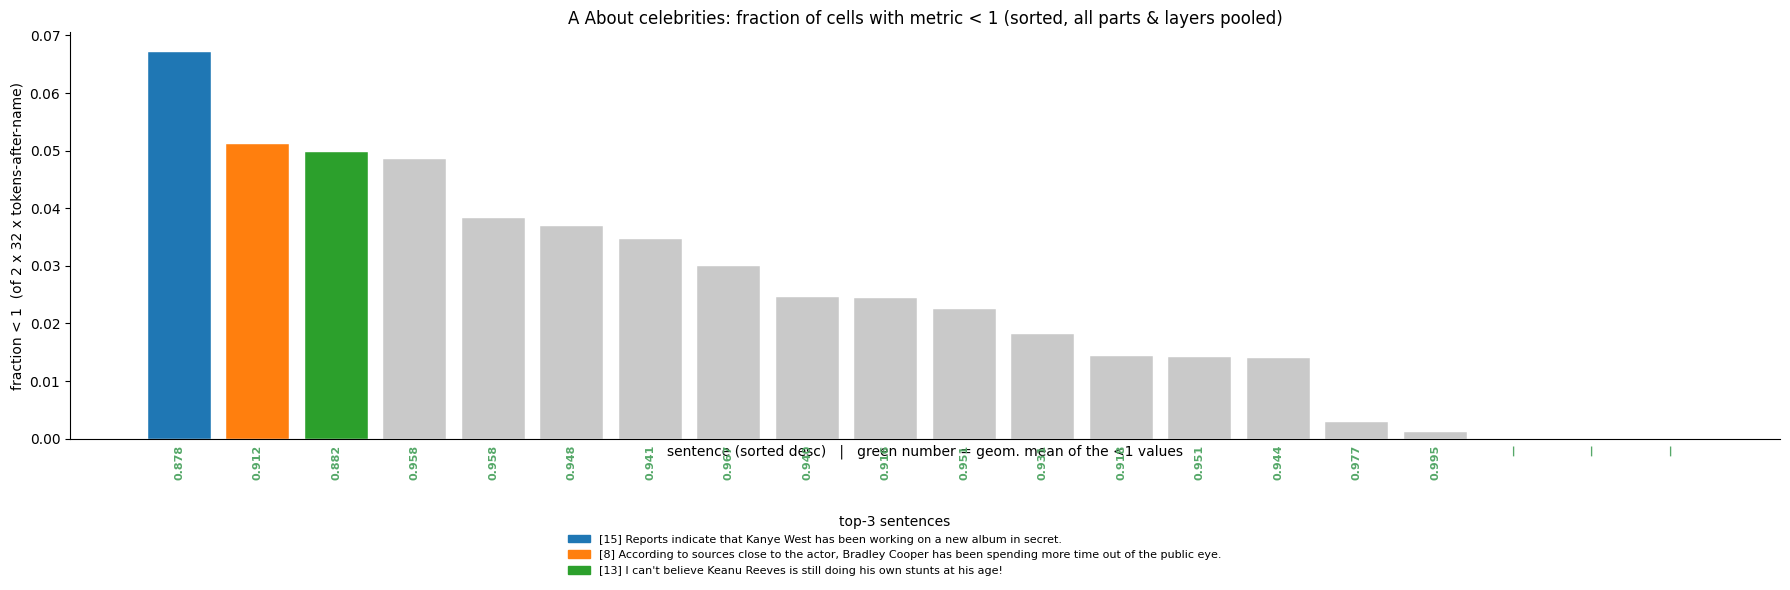

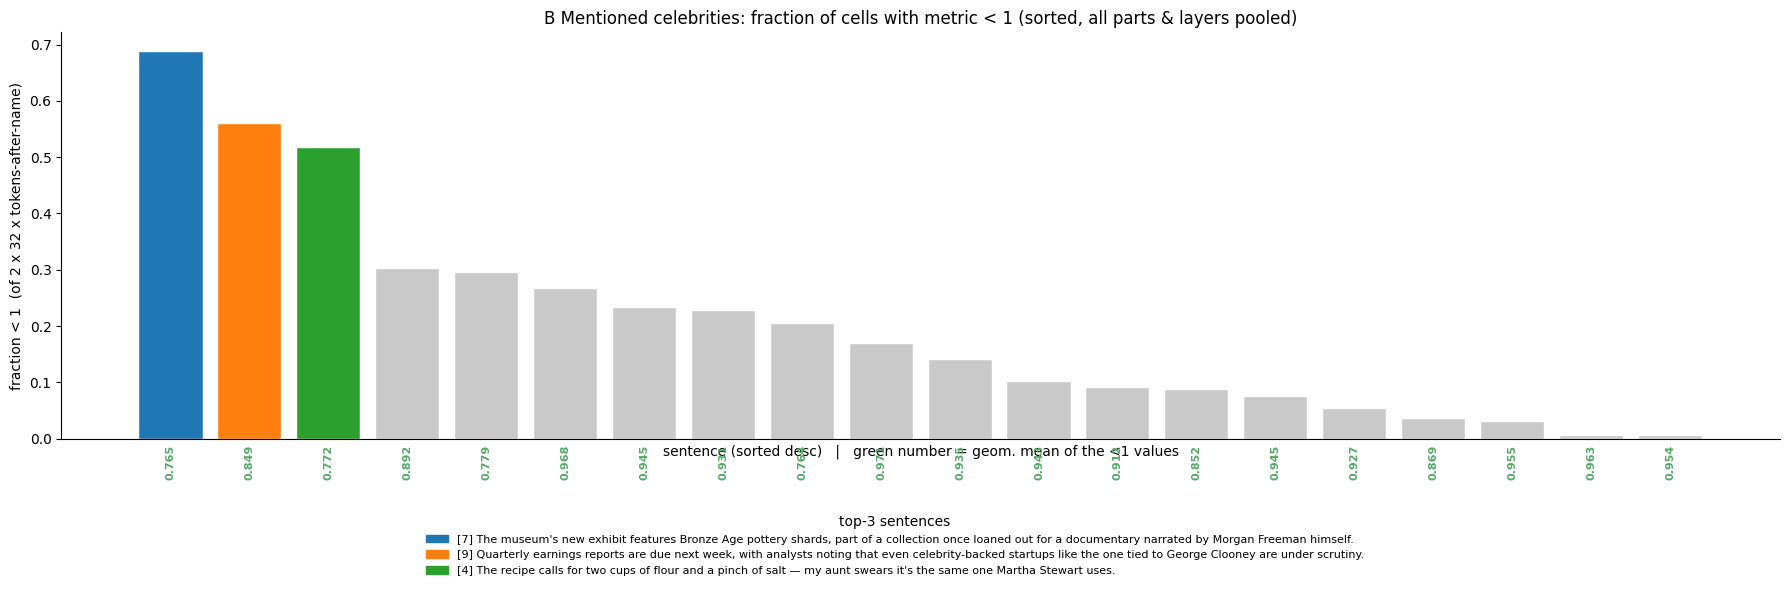

In [186]:
#VIBECODED
# NO layer split. Per sentence, over the whole metric tensor
#   (part {attn, mlp} x 32 layers x tokens-after-name):
#   - bar height = fraction of cells with metric < 1  = (#<1) / (2*32*tokens_after_name)
#   - green number below each bar = geometric mean of the metric values that are < 1
#   - bars SORTED descending by that fraction
#   - top-3 sentences color-coded, with a legend (full sentence text) below the plot
#   - A and B on INDEPENDENT y-scales (each auto-fit)

GRAY = "#c9c9c9"


def frac_and_geomean_below_one(metric_tensor):
    total = metric_tensor.numel()               # 2 * 32 * tokens_after_name
    below = metric_tensor[metric_tensor < 1]    # NaN/inf excluded automatically
    frac = below.numel() / total
    geo = float(torch.exp(torch.log(below).mean())) if below.numel() > 0 else float("nan")
    return frac, geo


def plot_frac_below_one(exp_label, metrics_list, sentences):
    fracs, geos = zip(*(frac_and_geomean_below_one(m) for m in metrics_list))
    fracs, geos = np.array(fracs), np.array(geos)
    order = np.argsort(fracs)[::-1]                       # descending by fraction
    top3 = list(order[:3])
    palette = plt.get_cmap("tab10").colors
    color_of = {idx: palette[k] for k, idx in enumerate(top3)}

    xs = np.arange(len(order))
    colors = [color_of.get(i, GRAY) for i in order]
    fig, ax = plt.subplots(figsize=(max(10, len(order) * 0.9), 5))
    ax.bar(xs, fracs[order], color=colors, edgecolor="white", linewidth=0.3)
    for xi, i in zip(xs, order):
        g = geos[i]
        txt = f"{g:.3f}" if np.isfinite(g) else "—"
        ax.text(xi, -0.015, txt, ha="center", va="top", rotation=90,
                fontsize=8, color="#55a868", fontweight="bold",
                transform=ax.get_xaxis_transform())
    ax.set_title(f"{exp_label}: fraction of cells with metric < 1 (sorted, all parts & layers pooled)")
    ax.set_xlabel("sentence (sorted desc)   |   green number = geom. mean of the <1 values")
    ax.set_ylabel("fraction < 1  (of 2 x 32 x tokens-after-name)")
    ax.set_xticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    # legend BELOW the plot: top-3 sentences, full text
    handles = [plt.Rectangle((0, 0), 1, 1, color=color_of[i]) for i in top3]
    labels = [f"[{i}] {sentences[i]}" for i in top3]
    fig.legend(handles, labels, frameon=False, fontsize=8, loc="upper center",
               bbox_to_anchor=(0.5, -0.02), title="top-3 sentences")
    plt.tight_layout()
    plt.show()


plot_frac_below_one("A About celebrities", a_about_celebrities_metrics_list,
                    [r.real_names_tokenpacks_info.sentence for r in a_ratios_ei])
plot_frac_below_one("B Mentioned celebrities", b_mentioned_celbrities_metrixs_list,
                    [r.real_names_tokenpacks_info.sentence for r in b_ratios_ei])


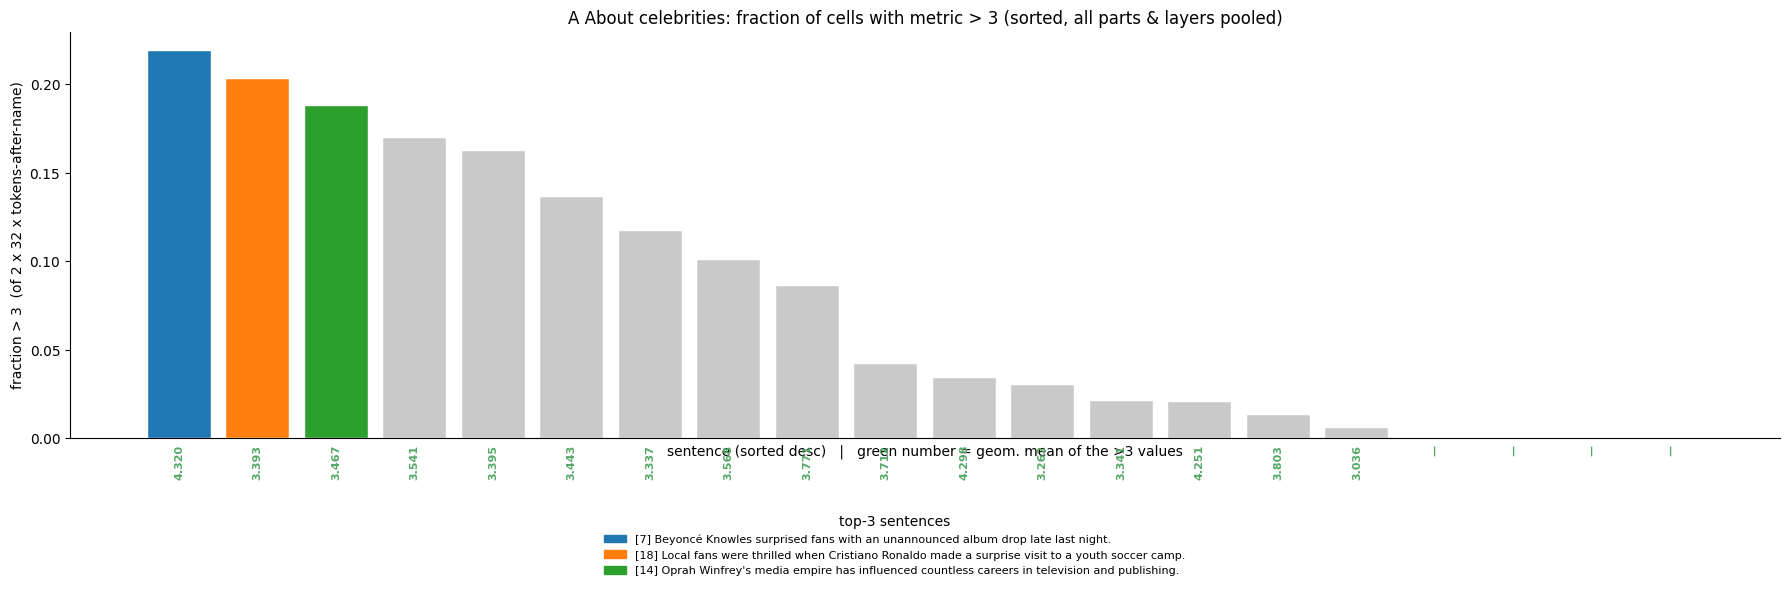

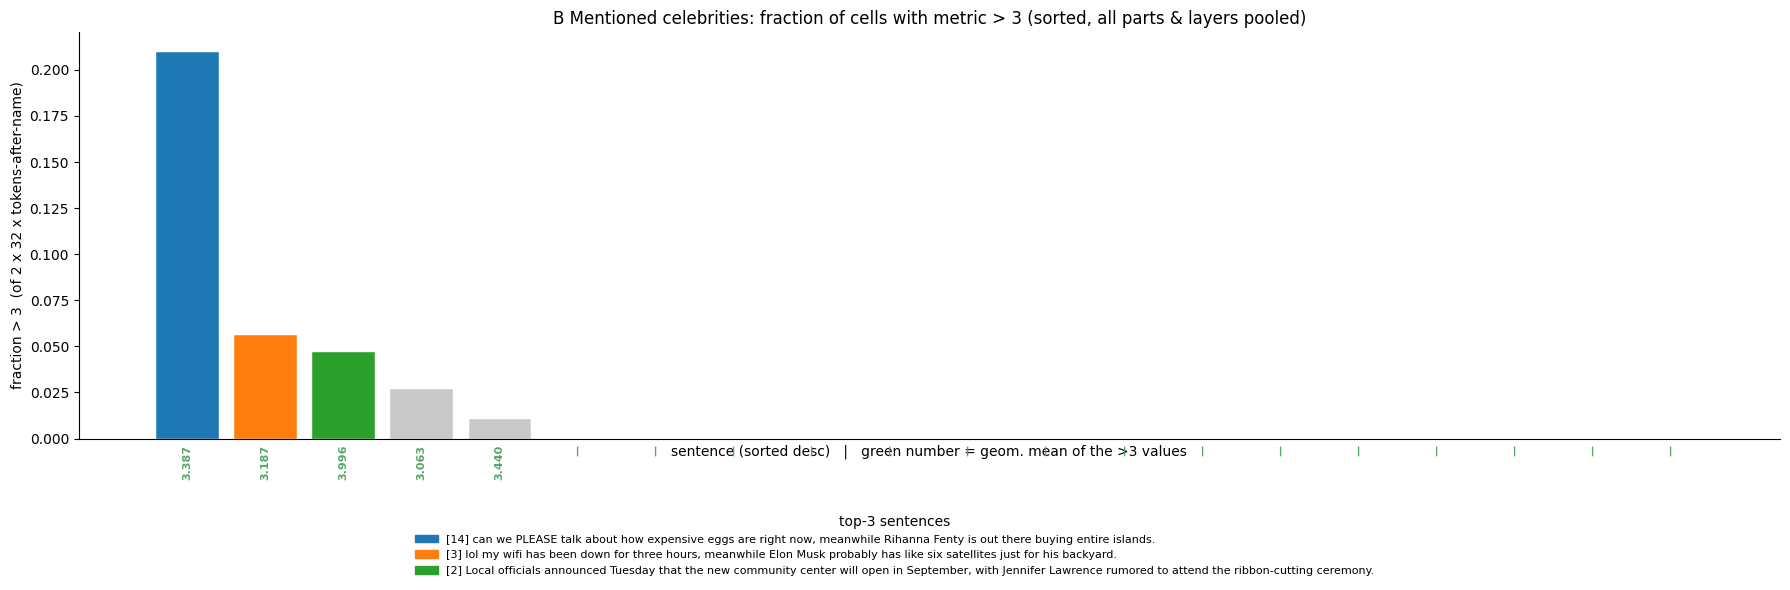

In [187]:
#VIBECODED
# Same as the "< 1" plot, but for the OTHER tail: metric > 3.
# Per sentence, over the whole metric tensor (part {attn, mlp} x 32 layers x tokens-after-name):
#   - bar height = fraction of cells with metric > 3  = (#>3) / (2*32*tokens_after_name)
#   - green number below each bar = geometric mean of the metric values that are > 3
#   - bars SORTED descending by that fraction
#   - top-3 sentences color-coded, with a legend (full sentence text) below the plot
#   - A and B on INDEPENDENT y-scales (each auto-fit)

THRESH = 3.0
GRAY = "#c9c9c9"


def frac_and_geomean_above(metric_tensor, thresh=THRESH):
    total = metric_tensor.numel()                    # 2 * 32 * tokens_after_name
    above = metric_tensor[metric_tensor > thresh]    # NaN excluded; +inf would pass, drop it next
    above = above[torch.isfinite(above)]             # drop +inf so geom-mean stays finite
    frac = above.numel() / total
    geo = float(torch.exp(torch.log(above).mean())) if above.numel() > 0 else float("nan")
    return frac, geo


def plot_frac_above(exp_label, metrics_list, sentences, thresh=THRESH):
    fracs, geos = zip(*(frac_and_geomean_above(m, thresh) for m in metrics_list))
    fracs, geos = np.array(fracs), np.array(geos)
    order = np.argsort(fracs)[::-1]                       # descending by fraction
    top3 = list(order[:3])
    palette = plt.get_cmap("tab10").colors
    color_of = {idx: palette[k] for k, idx in enumerate(top3)}

    xs = np.arange(len(order))
    colors = [color_of.get(i, GRAY) for i in order]
    fig, ax = plt.subplots(figsize=(max(10, len(order) * 0.9), 5))
    ax.bar(xs, fracs[order], color=colors, edgecolor="white", linewidth=0.3)
    for xi, i in zip(xs, order):
        g = geos[i]
        txt = f"{g:.3f}" if np.isfinite(g) else "—"
        ax.text(xi, -0.015, txt, ha="center", va="top", rotation=90,
                fontsize=8, color="#55a868", fontweight="bold",
                transform=ax.get_xaxis_transform())
    ax.set_title(f"{exp_label}: fraction of cells with metric > {thresh:g} (sorted, all parts & layers pooled)")
    ax.set_xlabel(f"sentence (sorted desc)   |   green number = geom. mean of the >{thresh:g} values")
    ax.set_ylabel(f"fraction > {thresh:g}  (of 2 x 32 x tokens-after-name)")
    ax.set_xticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    handles = [plt.Rectangle((0, 0), 1, 1, color=color_of[i]) for i in top3]
    labels = [f"[{i}] {sentences[i]}" for i in top3]
    fig.legend(handles, labels, frameon=False, fontsize=8, loc="upper center",
               bbox_to_anchor=(0.5, -0.02), title="top-3 sentences")
    plt.tight_layout()
    plt.show()


plot_frac_above("A About celebrities", a_about_celebrities_metrics_list,
                [r.real_names_tokenpacks_info.sentence for r in a_ratios_ei])
plot_frac_above("B Mentioned celebrities", b_mentioned_celbrities_metrixs_list,
                [r.real_names_tokenpacks_info.sentence for r in b_ratios_ei])

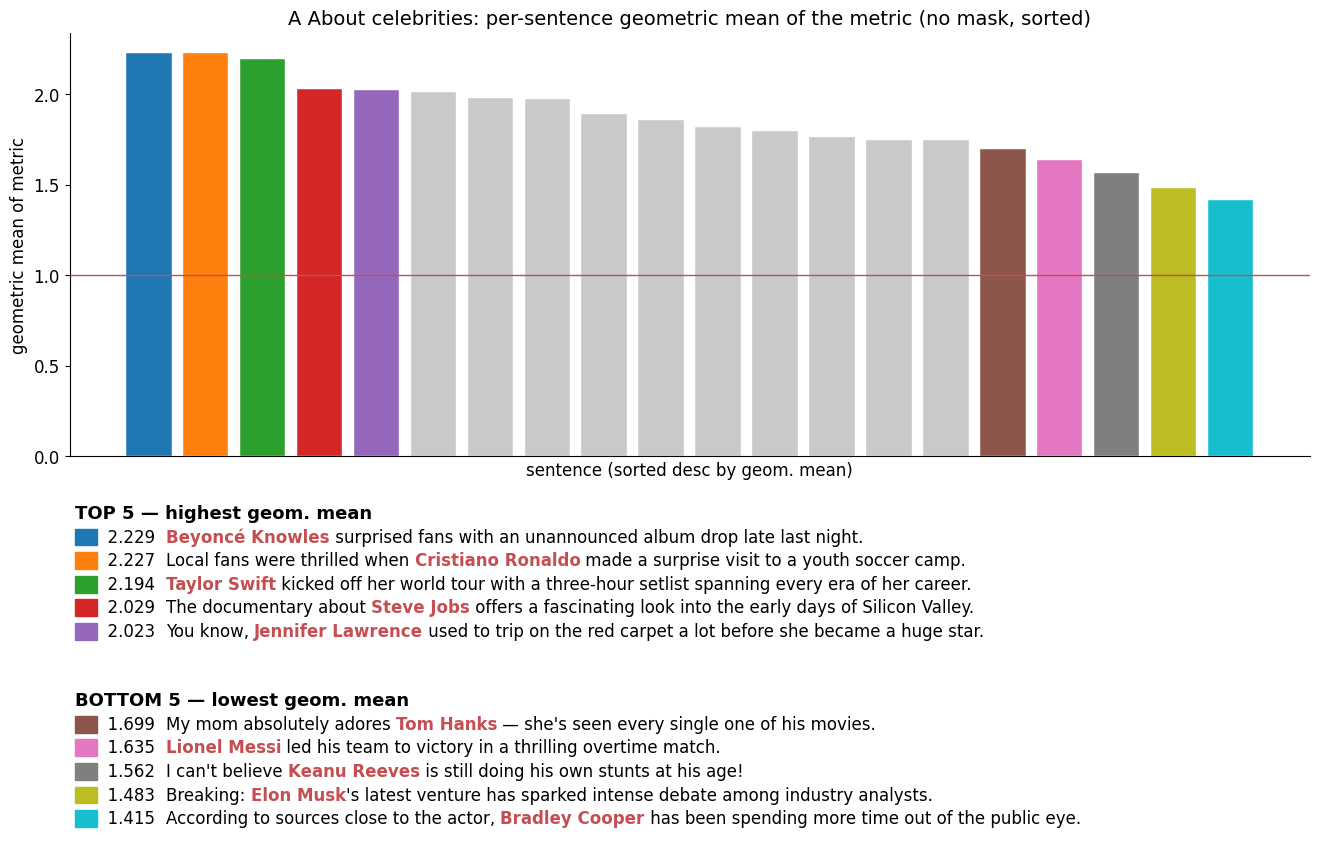

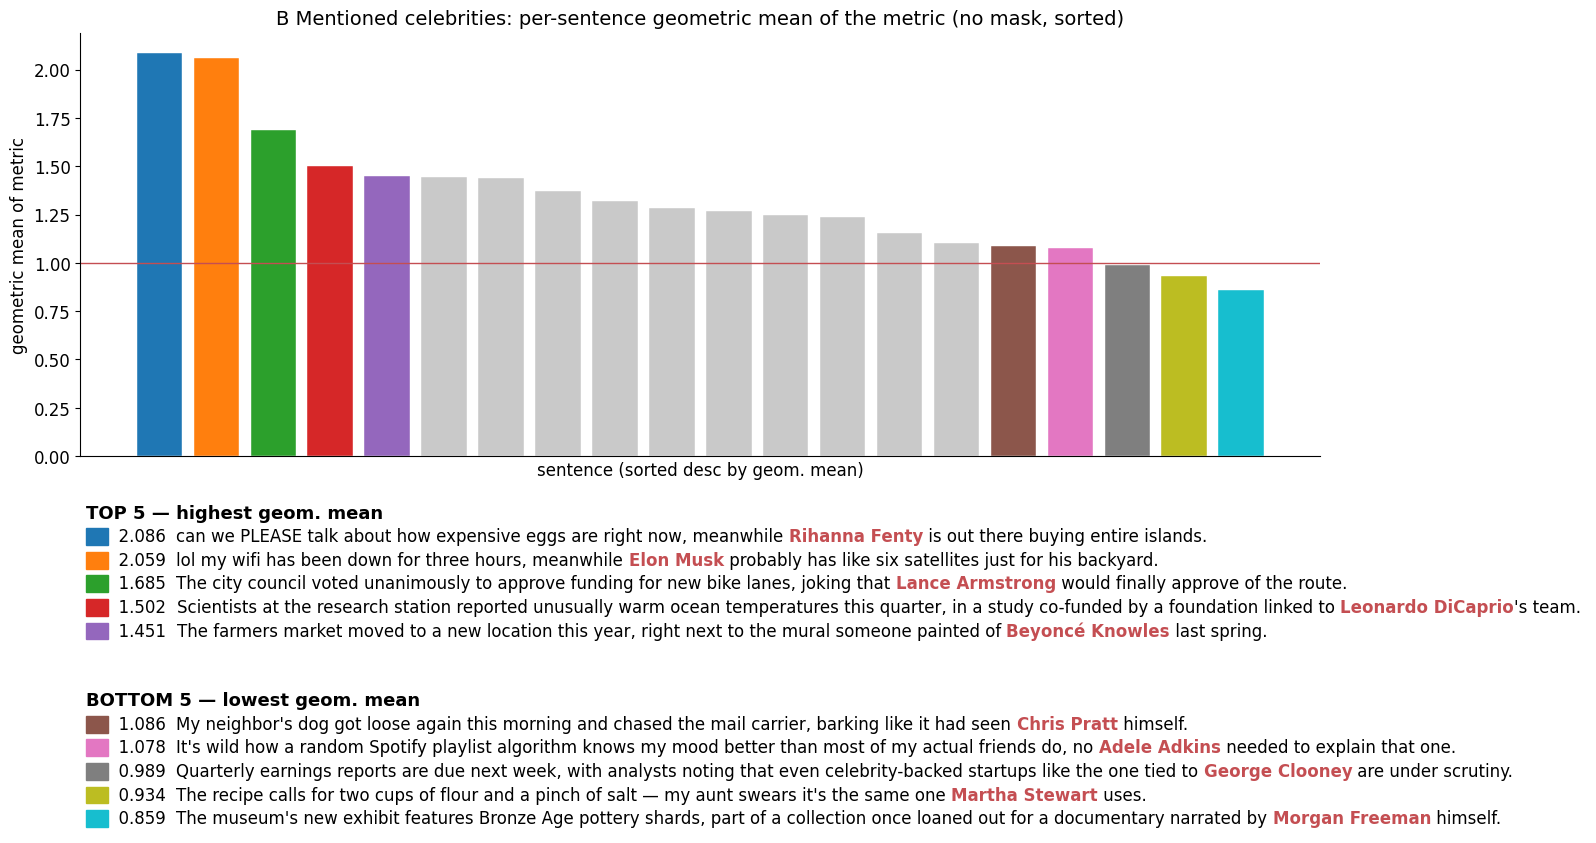

In [198]:
#VIBECODED
# Per sentence: geometric mean of the WHOLE metric tensor (NO threshold mask),
#   over all cells: part {attn,mlp} x 32 layers x tokens-after-name, finite values only.
# Bars sorted DESCENDING by geomean. Top-5 and bottom-5 sentences color-coded and listed
# BELOW in two stacked blocks (top-5 then bottom-5), full width, one line each.
# Sentence text is UNCHANGED; the celebrity name is drawn in a different color (red, bold).
from matplotlib.offsetbox import TextArea, HPacker, VPacker, AnchoredOffsetbox, DrawingArea
from matplotlib.patches import Rectangle as _Rect

GRAY = "#c9c9c9"
NAME_COLOR = "#c44e52"
FS = 12


def geomean_all(metric_tensor):
    v = metric_tensor[torch.isfinite(metric_tensor)]     # drop NaN/inf; NO <>threshold mask
    return float(torch.exp(torch.log(v).mean())) if v.numel() > 0 else float("nan")


def celeb_name(ratio_ei):
    tp = ratio_ei.real_names_tokenpacks_info
    return tp.tokenpacks[tp.name_token_index].strip()    # concatenated name tokens


def _txt(s, **kw):
    props = dict(fontsize=FS)
    props.update(kw)
    return TextArea(s, textprops=props)


def _row(color, value, sentence, name):
    swatch = DrawingArea(16, 12, 0, 0)
    swatch.add_artist(_Rect((0, 0), 16, 12, color=color))
    parts = [swatch, _txt(f"  {value:.3f}  ")]
    if name and name in sentence:
        pre, post = sentence.split(name, 1)
        parts += [_txt(pre), _txt(name, color=NAME_COLOR, fontweight="bold"), _txt(post)]
    else:
        parts += [_txt(sentence)]
    return HPacker(children=parts, align="center", pad=0, sep=0)


def _stack(title, idxs, geos, sentences, names, color_of):
    rows = [_txt(title, fontweight="bold", fontsize=FS + 1)]
    rows += [_row(color_of[i], geos[i], sentences[i], names[i]) for i in idxs]
    return VPacker(children=rows, align="left", pad=0, sep=4)


def plot_geomean_sorted(exp_label, metrics_list, ratios_ei):
    sentences = [r.real_names_tokenpacks_info.original_tokens_info.sentence for r in ratios_ei]
    names = [celeb_name(r) for r in ratios_ei]
    geos = np.array([geomean_all(m) for m in metrics_list])
    order = np.argsort(geos)[::-1]
    top5, bottom5 = list(order[:5]), list(order[-5:])
    palette = plt.get_cmap("tab10").colors
    color_of = {}
    for k, i in enumerate(top5):
        color_of[i] = palette[k]
    for k, i in enumerate(bottom5):
        color_of[i] = palette[5 + k]

    xs = np.arange(len(order))
    colors = [color_of.get(i, GRAY) for i in order]
    fig, ax = plt.subplots(figsize=(16, 5.5))
    ax.bar(xs, geos[order], color=colors, edgecolor="white", linewidth=0.3)
    ax.axhline(1.0, color=NAME_COLOR, linewidth=1.0)     # reference: geomean == 1
    ax.set_title(f"{exp_label}: per-sentence geometric mean of the metric (no mask, sorted)", fontsize=14)
    ax.set_xlabel("sentence (sorted desc by geom. mean)", fontsize=FS)
    ax.set_ylabel("geometric mean of metric", fontsize=FS)
    ax.set_xticks([])
    ax.tick_params(axis="y", labelsize=FS)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    top_box = _stack("TOP 5 — highest geom. mean", top5, geos, sentences, names, color_of)
    bot_box = _stack("BOTTOM 5 — lowest geom. mean", bottom5, geos, sentences, names, color_of)
    combined = VPacker(children=[top_box, _txt(" "), bot_box], align="left", pad=0, sep=12)
    ax.add_artist(AnchoredOffsetbox(loc="upper left", child=combined, pad=0.4, frameon=False,
                                    bbox_to_anchor=(0.0, -0.10), bbox_transform=ax.transAxes,
                                    borderpad=0))
    plt.show()   # inline backend crops with bbox_inches='tight', so the figure grows to fit the text


plot_geomean_sorted("A About celebrities", a_about_celebrities_metrics_list, a_ratios_ei)
plot_geomean_sorted("B Mentioned celebrities", b_mentioned_celbrities_metrixs_list, b_ratios_ei)

### No patterns are appearing, on first inspection shpuld be noted that alot of the data is hidden on this plot: which positions, number of tokens in the altenrative name might effect

### Compare with othe contribution changes
calculate the incresment norm for each word after contirbution
First weakest expiement, show that among all other ratios, increases the most on avrage, at least on most sentences
Calc ratio of full sentnece geometric mean / max(full sentence geomean of tokenpack) per other tokenpack
show that at most cases at least 80% its larger then 1

In [341]:
class AllNormsMetrics(BaseModel):
    metracies_list: list[torch.Tensor]
    name_tokenpack_indexes: list[int]
    real_tokenpacks_info: list[SentenceTokenPacksInformation]
    fake_name_tokenpack:list[str]
    model_config = SettingsConfigDict(arbitrary_types_allowed=True)


def get_all_post_norms_metrics(
    ratios_ei: list[ContributionsPositionsRatiosExpirmentInfo],
) -> list[torch.Tensor]:  # sentence,({attention,mlp},layer,positon(after name),tokenpacs):
    result_list: list[torch.Tensor] = []
    for ratio_ei in ratios_ei:
        name_real_end_token_index, name_fake_end_token_index = max(
            ratio_ei.real_names_tokenpacks_info.original_tokens_info.name_tokens_indexes
        ), max(ratio_ei.fake_names_tokenpacks_info.original_tokens_info.name_tokens_indexes)
        attention_metric_tensor = (
            ratio_ei.real_norm_ratios.post_attention_ratios[:, (name_real_end_token_index + 1) :, :]
            / ratio_ei.fake_norm_ratios.post_attention_ratios[:, (name_fake_end_token_index + 1) :, :]
        )
        mlp_metric_tensor = (
            ratio_ei.real_norm_ratios.post_mlp_ratios[:, (name_real_end_token_index + 1) :, :]
            / ratio_ei.fake_norm_ratios.post_mlp_ratios[:, (name_fake_end_token_index + 1) :, :]
        )
        metric_tensor = torch.stack([attention_metric_tensor, mlp_metric_tensor])
        assert len(metric_tensor.shape) == 4
        result_list.append(metric_tensor)
    return AllNormsMetrics(
        metracies_list=result_list, 
        name_tokenpack_indexes=[ratio_ei.real_names_tokenpacks_info.name_token_index for ratio_ei in ratios_ei],
        real_tokenpacks_info = [ratio_ei.real_names_tokenpacks_info for ratio_ei in ratios_ei],
        fake_name_tokenpack= [ratio_ei.fake_names_tokenpacks_info.tokenpacks[ratio_ei.fake_names_tokenpacks_info.name_token_index] for ratio_ei in ratios_ei]
    )


a_all_about_celebrities_metrics_list = get_all_post_norms_metrics(a_ratios_ei)
b_all_mentioned_celbrities_metrixs_list = get_all_post_norms_metrics(b_ratios_ei)

### Selected normalziation method:
There are two possible options:
a. divide geometric mean by the geometic mean
b. divide geometric mean by the geometric mean in the relevant position


In the next compression Ill do divide  by relevant position

This expirment ins about contribution precentage on the whole sentnece, whatever that might mean

#### Trying to show 1:show that this is the one of the most increasing tokens
method: avrage mean of precentile x "is bigger then" of other contributions

In [342]:
def geometric_mean(values:torch.Tensor)->float:
    return float(torch.exp(torch.log(values).mean()))

def get_metricies_precentiles(all_about_celebrities_metrics_list:AllNormsMetrics)->list[float]: 
    result = []
    for metricies,name_index in zip(all_about_celebrities_metrics_list.metracies_list,all_about_celebrities_metrics_list.name_tokenpack_indexes):
        sentences_tokenpacks_metrecies = [metricies[...,i] for i in range(metricies.shape[-1])]
        after_own_position_metacies = sentences_tokenpacks_metrecies[:name_index+1] + [sentences_tokenpacks_metrecies[i][...,i-name_index-1:] for i in range(name_index+1,len(sentences_tokenpacks_metrecies))] # Trim zeros (tokenpack before its positon) sentnece, ({attention,mlp},layer,position (after name after token appers)}),
        after_own_position_geometric_mean = [geometric_mean(a) for a in after_own_position_metacies]
        after_own_position_name_geometric_mean = after_own_position_geometric_mean[name_index]
        other_positions_geomtric_means =  after_own_position_geometric_mean[:name_index] + after_own_position_geometric_mean[name_index +1:]
        precentile = sum(after_own_position_name_geometric_mean > after_positon_other_mean for after_positon_other_mean in other_positions_geomtric_means)/ len(other_positions_geomtric_means)
        result.append(precentile)
    return result
def get_mean(l:list[float])->float:
    return sum(l)/len(l)      

#### Print avrage precent of tokens from which it large on all sentnece
Excepted result: On a around 95-100
On b around 90-100

In [343]:
a_metrics_precentils = get_metricies_precentiles(a_all_about_celebrities_metrics_list)
a_precentil_mean = get_mean(a_metrics_precentils)
print(f"A metracies preceintile avrage {round(100*a_precentil_mean,2)}%")

A metracies preceintile avrage 100.0%


In [344]:
b_metrics_percentils = get_metricies_precentiles(b_all_mentioned_celbrities_metrixs_list)
b_percentil_mean = get_mean(b_metrics_percentils)
print(f"B metrice precnetiles avrage {round(100*b_percentil_mean,2)}%")

B metrice precnetiles avrage 87.61%


#### Results

In A it is proven to be quite robust, and the method produced the larget, in B it hasent

### Incistigate B group diffrence causes

Inspect which values cause the diffrence

In [308]:
print(b_metrics_percentils)

[1.0, 1.0, 1.0, 1.0, 0.11538461538461539, 1.0, 1.0, 0.10714285714285714, 1.0, 0.3333333333333333, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9655172413793104]


Ok, this seem wierd, all close to 1, except for very specific sentence, indexed

In [309]:
print([i for i in range(len(b_metrics_percentils)) if b_metrics_percentils[i] < 0.5])
small_indexes_list = [i for i in range(len(b_metrics_percentils)) if b_metrics_percentils[i] < 0.5]

[4, 7, 9]


In [310]:
def geometric_mean(values:torch.Tensor)->float:
    return float(torch.exp(torch.log(values).mean()))

def get_metricies_precentiles_after(all_about_celebrities_metrics_list:AllNormsMetrics)->list[float]: 
    result = []
    for metricies,name_index in zip(all_about_celebrities_metrics_list.metracies_list,all_about_celebrities_metrics_list.name_tokenpack_indexes):
        sentences_tokenpacks_metrecies = [metricies[...,i] for i in range(metricies.shape[-1])]
        after_own_position_metacies = sentences_tokenpacks_metrecies[:name_index+1] + [sentences_tokenpacks_metrecies[i][...,i-name_index-1:] for i in range(name_index+1,len(sentences_tokenpacks_metrecies))] # Trim zeros (tokenpack before its positon) sentnece, ({attention,mlp},layer,position (after name after token appers)}),
        after_own_position_geometric_mean = [geometric_mean(a) for a in after_own_position_metacies]
        after_own_position_name_geometric_mean = after_own_position_geometric_mean[name_index]
        other_positions_geomtric_means =  after_own_position_geometric_mean[name_index +1:]
        precentile = sum(after_own_position_name_geometric_mean > after_positon_other_mean for after_positon_other_mean in other_positions_geomtric_means)/ len(other_positions_geomtric_means)
        result.append(precentile)
    return result
def get_mean(l:list[float])->float:
    return sum(l)/len(l)      

In [311]:
print(get_metricies_precentiles_after(b_all_mentioned_celbrities_metrixs_list))


[1.0, 1.0, 1.0, 1.0, 0.5, 1.0, 1.0, 0.0, 1.0, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


Geometric means after are always one, except for already suspected positon

Suspecting its the case its 0 for some reason after

In [312]:
print(small_indexes_list)
small_sentneces = [b_mentions_celebrities[sil] for sil in small_indexes_list]
for a in small_sentneces:
    print(a)

[4, 7, 9]
sentence="The recipe calls for two cups of flour and a pinch of salt — my aunt swears it's the same one Martha Stewart uses." name_start_index=94 name_end_index=108 name='Martha Stewart'
sentence="The museum's new exhibit features Bronze Age pottery shards, part of a collection once loaned out for a documentary narrated by Morgan Freeman himself." name_start_index=128 name_end_index=142 name='Morgan Freeman'
sentence='Quarterly earnings reports are due next week, with analysts noting that even celebrity-backed startups like the one tied to George Clooney are under scrutiny.' name_start_index=124 name_end_index=138 name='George Clooney'


Ill case study
sentence="The recipe calls for two cups of flour and a pinch of salt — my aunt swears it's the same one Martha Stewart uses." name_start_index=94 name_end_index=108 name='Martha Stewart'
And see if i can deduce somthing

print()

In [313]:
WIERD_SENTENCE_INDEX = 4

In [314]:
print(b_tokens_info[0][WIERD_SENTENCE_INDEX])
print(b_tokens_info[1][WIERD_SENTENCE_INDEX])
print()

sentence="The recipe calls for two cups of flour and a pinch of salt — my aunt swears it's the same one Martha Stewart uses." tokens=['<|begin_of_text|>', 'The', ' recipe', ' calls', ' for', ' two', ' cups', ' of', ' flour', ' and', ' a', ' pinch', ' of', ' salt', ' —', ' my', ' aunt', ' sw', 'ears', ' it', "'s", ' the', ' same', ' one', ' Martha', ' Stewart', ' uses', '.'] name_tokens_indexes=[24, 25]
sentence="The recipe calls for two cups of flour and a pinch of salt — my aunt swears it's the same one Harlow Vance uses." tokens=['<|begin_of_text|>', 'The', ' recipe', ' calls', ' for', ' two', ' cups', ' of', ' flour', ' and', ' a', ' pinch', ' of', ' salt', ' —', ' my', ' aunt', ' sw', 'ears', ' it', "'s", ' the', ' same', ' one', ' Har', 'low', ' Vance', ' uses', '.'] name_tokens_indexes=[24, 25, 26]



In [315]:
print([b_tokens_info[0][WIERD_SENTENCE_INDEX].tokens[i] for i in b_tokens_info[0][WIERD_SENTENCE_INDEX].name_tokens_indexes])
print([b_tokens_info[1][WIERD_SENTENCE_INDEX].tokens[i] for i in list(b_tokens_info[1][WIERD_SENTENCE_INDEX].name_tokens_indexes)])

[' Martha', ' Stewart']
[' Har', 'low', ' Vance']


In [ ]:
for i in range(len(b_all_mentioned_celbrities_metrixs_list.metracies_list)):
    print(b_all_mentioned_celbrities_metrixs_list.metracies_list[i])

In [ ]:
b_all_mentioned_celbrities_metrixs_list.metracies_list[0].shape # position, ({attention,mlp},layer, position after, tokenpacks)
b_all_mentioned_celbrities_metrixs_list.metracies_list[0][0][0]

there is none, why?

Not that unacepted, its alredy divided 0 by 0 since tokenpack contribution to this positon


In [ ]:
#Not that

In [363]:
class SentenceAvregedMetrics(BaseModel):
    metracies_list: list[list[float]] #sentence, (tokenpacks)
    name_tokenpack_indexes: list[int]
    real_tokenpacks_info: list[SentenceTokenPacksInformation]
    fake_name_tokenpack:list[str]
    
    model_config = SettingsConfigDict(arbitrary_types_allowed=True)
def get_metricies_per_tokenpack_geo_mean_lists(all_about_celebrities_metrics_list:AllNormsMetrics)->SentenceAvregedMetrics: 
    metricies_list = []
    for metricies,name_index in zip(all_about_celebrities_metrics_list.metracies_list,all_about_celebrities_metrics_list.name_tokenpack_indexes):
        sentences_tokenpacks_metrecies = [metricies[...,i] for i in range(metricies.shape[-1])]
        after_own_position_metacies = sentences_tokenpacks_metrecies[:name_index+1] + [sentences_tokenpacks_metrecies[i][...,i-name_index-1:] for i in range(name_index+1,len(sentences_tokenpacks_metrecies))] # Trim zeros (tokenpack before its positon) sentnece, ({attention,mlp},layer,position (after name after token appers)}),
        after_own_position_geometric_mean = [geometric_mean(a) for a in after_own_position_metacies]
        metricies_list.append(after_own_position_geometric_mean)
    return SentenceAvregedMetrics(metracies_list=metricies_list,
                                  name_tokenpack_indexes=all_about_celebrities_metrics_list.name_tokenpack_indexes,
                                  real_tokenpacks_info=all_about_celebrities_metrics_list.real_tokenpacks_info,
                                  fake_name_tokenpack=all_about_celebrities_metrics_list.fake_name_tokenpack,
                                  )


b_metricis_geo_means_lists = get_metricies_per_tokenpack_geo_mean_lists(b_all_mentioned_celbrities_metrixs_list)

In [364]:
a_metricis_geo_means_lists = get_metricies_per_tokenpack_geo_mean_lists(a_all_about_celebrities_metrics_list)

In [393]:
#VIBECODED
# Interactive beeswarm -- AXES SWAPPED: x = relative position in sentence (linear),
#   y = per-tokenpack geometric mean (log scale). Reference line now horizontal at y=1.
# Hover -> tokenpack, idx, geomean, rel pos, real/fake name, sentence w/ hovered tokenpack bold+red.
# Legend: one entry per sentence (shared legendgroup) -> dbl-click a label isolates that sentence.
# "Show all" button clears isolation. Axes fixed so they don't move on toggle/isolate.
# PROJECT RULE: never silently drop 0 / non-finite / non-positive geomeans -- raise on them.
import plotly.graph_objects as go

HL_COLOR = "#c44e52"


def _rgb(c):
    return f"rgb({int(c[0] * 255)},{int(c[1] * 255)},{int(c[2] * 255)})"


def _sentence_with_highlight(tokenpacks, hi):
    parts = []
    for j, tp in enumerate(tokenpacks):
        if j == 0:
            continue  # BOS -- not part of the visible sentence
        parts.append(f"<b><span style='color:{HL_COLOR}'>{tp}</span></b>" if j == hi else tp)
    return "".join(parts)


def plot_metric_beeswarm_interactive(geo_means, title):
    metr = geo_means.metracies_list
    name_idx = geo_means.name_tokenpack_indexes
    tp_infos = geo_means.real_tokenpacks_info
    fake_names = geo_means.fake_name_tokenpack
    assert len(metr) == len(name_idx) == len(tp_infos) == len(fake_names), "sentence-count mismatch"

    palette = plt.get_cmap("tab20").colors
    fig = go.Figure()
    y_min, y_max = float("inf"), float("-inf")   # FLAG: aggregation, used ONLY for fixed y (geomean) axis bounds
    for s, (vals, ni, tp_info, fake) in enumerate(zip(metr, name_idx, tp_infos, fake_names)):
        tokenpacks = tp_info.tokenpacks
        assert len(vals) == len(tokenpacks), f"tokenpack-count mismatch sentence {s}: {len(vals)} vs {len(tokenpacks)}"
        n = len(vals)
        name_pt, xs, ys, otext = None, [], [], []   # xs = rel position, ys = geomean
        for i, v in enumerate(vals):
            v = float(v)
            if not np.isfinite(v) or v <= 0:
                raise ValueError(
                    f"Invalid geomean {v!r} at sentence {s}, tokenpack {i} ({tokenpacks[i]!r}); "
                    f"refusing to silently drop it."
                )
            y_min, y_max = min(y_min, v), max(y_max, v)   # FLAG: axis-bounds aggregation only
            rel = i / (n - 1) if n > 1 else 0.0
            hover = (f"tokenpack: {tokenpacks[i]!r}<br>"
                     f"sentence idx: {s} | tokenpack idx: {i}{' (NAME)' if i == ni else ''}<br>"
                     f"geomean: {v:.4f} | rel pos: {rel:.3f}<br>"
                     f"real name: {tokenpacks[ni]!r} | fake name: {fake!r}<br><br>"
                     f"{_sentence_with_highlight(tokenpacks, i)}")
            if i == ni:
                name_pt = (rel, v, hover)          # (x=rel, y=geomean)
            else:
                xs.append(rel); ys.append(v); otext.append(hover)
        assert name_pt is not None, f"no name tokenpack found for sentence {s}"

        grp, color = f"s{s}", _rgb(palette[s % len(palette)])
        fig.add_trace(go.Scatter(x=[name_pt[0]], y=[name_pt[1]], mode="markers", name=f"[{s}]",
                                 legendgroup=grp, showlegend=True,
                                 marker=dict(size=13, color=color, line=dict(width=1, color="black")),
                                 text=[name_pt[2]], hoverinfo="text"))
        fig.add_trace(go.Scatter(x=xs, y=ys, mode="markers", legendgroup=grp, showlegend=False,
                                 marker=dict(size=6, color="rgba(150,150,150,0.55)"),
                                 text=otext, hoverinfo="text"))

    # fixed ranges so the axes DON'T move on legend toggle/isolate
    pad = 0.05 * (np.log10(y_max) - np.log10(y_min) or 1.0)          # padding in log10 units
    y_range = [np.log10(y_min) - pad, np.log10(y_max) + pad]         # log axis range is in log10
    fig.add_hline(y=1.0, line=dict(color=HL_COLOR, width=1))         # reference: metric == 1
    fig.update_xaxes(range=[-0.05, 1.05], autorange=False,
                     title="relative position in sentence (0 = start, 1 = end)")
    fig.update_yaxes(type="log", range=y_range, autorange=False,
                     title="geometric mean of metric (log scale)")
    fig.update_layout(
        title=title, width=500, height=650,          # <-- x-axis halved (was 1000)
        legend_title="sentence idx (dbl-click = isolate)", template="simple_white",
        updatemenus=[dict(type="buttons", direction="left", showactive=False,
                          x=1.0, xanchor="right", y=1.12, yanchor="top",
                          buttons=[dict(label="Show all", method="restyle", args=[{"visible": True}])])],
    )
    fig.show()



Beurtifull! Dosent explain the outlayers, but seems like a real distingshen!

In [394]:
plot_metric_beeswarm_interactive(b_metricis_geo_means_lists,
                                 "B mentioned celebrities: per-tokenpack metric geom-mean (interactive)")

Lets plot for A as well

In [395]:
# A
plot_metric_beeswarm_interactive(a_metricis_geo_means_lists,
                                 "A about celebrities: per-tokenpack metric geom-mean (interactive)")

### Tryign to  simulate other sentences, to see if outlayers stay or changes

In [290]:
import hashlib

from info_flow.config import Config
config = Config()
print(hashlib.sha256(f"{config.info_flow_model}|||{b_tokens_info[0][WIERD_SENTENCE_INDEX].sentence}".encode("utf-8")).hexdigest())

97a5d77da4c8601cb2bc5810d119ca43bc90cb6b29e9921d898cc531a97ce7cb


In [248]:
SIZE = 12
q = torch.randint(low=1,high=20,size=(SIZE,))
print(geometric_mean(q))
res =1
for a in q:
    res*=a
    
print(res**(1/SIZE))

7.908522129058838
tensor(7.9085)
